# The Last Inch — silent failures between the model output and the scalar

**ERA-V5 · Assignment 9 · the loss harness.** One notebook, one loss harness, and one thing
you have to get right by *reading* rather than by guessing.

Everything in language-model training funnels through three lines:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss   = cross_entropy(logits[:, :-1].reshape(-1, vocab_size),
                       tokens[:, 1:].reshape(-1))
```

This notebook takes those three lines and makes them **correct and observable**. The
uncomfortable claim it demonstrates, with numbers: **every classic bug in these lines
produces a smooth, beautiful loss curve** — two of the bugs produce *better-looking* curves
than the correct code — and no exception is ever raised. The only defenses are direct
observation: printing shapes with meanings, printing the actual token **strings** input
beside target, accounting for every token that enters the denominator, and measuring the
model's *behavior* (copy-circuit accuracies, generation), not just its scalar.

**How to read this notebook.** It runs top to bottom on CPU or GPU with no pip installs and
no downloads (Colab's stock `torch`/`numpy`/`matplotlib` are enough). Sections 3–9 are the
seven Part-1 requirements in order; Section 10 is Part 2 (a second head predicting `t+2`,
i.e. two-head multi-token prediction); Section 11 is Part 3 (the bug zoo: the warning made
quantitative). Section 12 writes every number to `submission_artifacts/` so the README can be
audited against this run.

| # | requirement | section | artifact key |
|---|---|---|---|
| 1 | every tensor shape, one line per dimension | §3 | `part1.shapes` |
| 2 | verify the shift with token **strings** | §4 | `part1.shift_audit` |
| 3 | mask padding, contributing count changes | §5 | `part1.padding` |
| 4 | pack two docs, mask the boundary, loss before/after | §6 | `part1.packing` |
| 5 | untrained perplexity ≈ vocab size | §7 | `part1.perplexity` |
| 6 | tied vs untied head parameter counts | §8 | `part1.tied_untied` |
| 7 | peak memory: ordinary vs chunked cross-entropy | §9 | `part1.memory` |
| P2 | second head predicting t+2, both losses + sum | §10 | `part2` |
| P3 | wrong-direction shift ⇒ beautiful loss curve | §11 | `part3` |

## §0 — Setup

One config cell. `A9_FAST=1` in the environment shrinks every budget (used by
`run_demo.py --fast` for smoke-testing); the committed run uses the full budgets shown in
the output below. Seed is fixed everywhere; on CPU this makes the whole notebook
bit-reproducible.

In [1]:
import json
import math
import os
import random
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

FAST = os.environ.get("A9_FAST", "") == "1"
SEED = 1337
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {
    "d_model": 128, "n_layer": 2, "n_head": 4, "max_pos": 512,
    "T": 64 if FAST else 128,          # context length
    "B": 4 if FAST else 8,             # batch size
    "steps_zoo": 40 if FAST else 300,  # per bug-zoo arm (incl. the correct arm)
    "steps_part2": 60 if FAST else 600,
    "lr": 3e-3,
    "log_every": 10 if FAST else 20,
    "mem_rows": 2048 if FAST else 4096,     # N for the memory experiment
    "mem_vocab": 32768 if FAST else 50257,  # full mode: the GPT-2 vocabulary
    "chunk_rows": 128,
    "vocab_chunk": 1024 if FAST else 2048,  # online-softmax CE vocab slice
}

ART = Path(os.environ.get("A9_ART_DIR", "submission_artifacts"))
RESULTS = {"config": {**CFG, "seed": SEED, "device": DEVICE, "fast": FAST,
                      "torch": torch.__version__}}
HEADLINE = {}   # name -> formatted string; the README must quote these verbatim
PTL = {}        # per-token losses, saved for the independent audit
CURVES = {}
T0 = time.time()


def fmt(x, nd=4):
    """One formatter for every float that reaches the README (verbatim-audited)."""
    return f"{x:.{nd}f}"


def seed_all(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [2]:
print(f"device={DEVICE}  torch={torch.__version__}  fast={FAST}")
print(json.dumps(CFG, indent=2))

device=cpu  torch=2.13.0+cpu  fast=False
{
  "d_model": 128,
  "n_layer": 2,
  "n_head": 4,
  "max_pos": 512,
  "T": 128,
  "B": 8,
  "steps_zoo": 300,
  "steps_part2": 600,
  "lr": 0.003,
  "log_every": 20,
  "mem_rows": 4096,
  "mem_vocab": 50257,
  "chunk_rows": 128,
  "vocab_chunk": 2048
}


## §1 — Tokens you can read: byte-level tokenizer + an inline corpus

Requirement 2 says: *print the strings, not the ids*. That demands a tokenizer whose
`decode_token` is total and readable — every id maps to a printable string. A byte-level
tokenizer gives that with zero downloads: ids `0..2` are `<pad>/<bos>/<eos>`, id `3+b` is
byte `b`, so **V = 259**. Spaces render as `␣` and newlines as `\n` in token tables, so an
off-by-one cannot hide in whitespace.

The corpus is ~6.6 KB authored inside this cell (public-domain by construction): ten short
documents in **two visibly different registers** — plain prose about loss functions, and a
pseudo-code register. Two registers matter later: when §6 packs one document of each kind
into a single sequence, the document boundary is visible *in the strings*, not just in the
numbers. Two documents (one per register) are held out for evaluation.

In [3]:
PAD_ID, BOS_ID, EOS_ID = 0, 1, 2
SPECIALS = {PAD_ID: "<pad>", BOS_ID: "<bos>", EOS_ID: "<eos>"}
BYTE_OFFSET = 3
VOCAB_SIZE = BYTE_OFFSET + 256  # 259


def encode(text, add_bos=True, add_eos=True):
    ids = [BYTE_OFFSET + b for b in text.encode("utf-8")]
    return ([BOS_ID] if add_bos else []) + ids + ([EOS_ID] if add_eos else [])


def decode_token(tid):
    """Total and printable: every id in [0, 259) renders as a visible string."""
    if tid in SPECIALS:
        return SPECIALS[tid]
    ch = bytes([tid - BYTE_OFFSET]).decode("utf-8", errors="replace")
    return {"\n": "\\n", "\t": "\\t", " ": "␣"}.get(ch, ch)


def decode(ids, keep_special=False):
    out = bytearray()
    for t in ids:
        if t < BYTE_OFFSET:
            if keep_special and t == EOS_ID:
                out.extend(b"\n")
            continue
        out.append(t - BYTE_OFFSET)
    return out.decode("utf-8", errors="replace")

In [4]:
PROSE = "prose"
CODE = "code"

CORPUS_DOCS = [
    (PROSE, """A loss is a promise about the future. When a language model reports a
cross-entropy of two nats, it is promising that, on average, the true next token sits
inside a set of about seven candidates the model considers likely. The scalar is a
compressed claim about every prediction the model made, and like every compressed claim
it can hide a great deal. Two models with the same mean loss can disagree wildly about
which tokens are hard. The mean is where analysis starts, never where it ends. The whole
craft of training is to make that single number honest: every token that enters the
average must be a token the model was genuinely asked to predict, with a context it was
genuinely allowed to see, and nothing else may leak in."""),
    (PROSE, """The most dangerous bugs in a training loop do not crash. A crash is a gift:
it names a line, it names a shape, it stops the run before the run wastes a week. The
silent bug instead produces a loss curve of great beauty, sloping down exactly the way
the textbooks promise, while the model underneath learns to copy a token it has already
read. The curve is not evidence of learning. The curve is evidence that the optimizer
found the easiest path through whatever objective you actually wrote, which is not
always the objective you meant to write. The only defense is to look at the data the
loss sees: print the inputs beside the targets, as strings, and read them."""),
    (PROSE, """Every position in a causal language model lives one step in the past. The
hidden state at position ten has read tokens zero through ten, and its job is to guess
token eleven. Shift the targets one way and each position is asked about the token it
just read, which needs no intelligence at all, only a wire from input to output. Shift
them the other way and each position is asked about a token two steps ahead, which is a
different and harder question. The correct alignment is a single line of indexing, and
nothing in the type system distinguishes it from the two wrong ones. Alignment is a
semantic property. Only the strings can show it."""),
    (PROSE, """Padding exists for the convenience of rectangles. Real documents end where
they end; tensors do not. The pad token squares the batch, and then the mask must undo
the pad token everywhere it would otherwise pretend to be data: the attention should not
read it, the loss should not count it. A model scored on its ability to predict padding
will get very good at predicting padding, and the mean loss will fall while nothing of
value is learned. Count the tokens that actually contribute to the loss. If that count
does not change when the mask changes, the mask is decoration, and the average is
diluted by predictions nobody needed."""),
    (PROSE, """When two documents share one sequence, the boundary between them is a small
lie. The last token of the first document does not know the second document exists, and
no amount of training will make the opening of one essay predictable from the close of
another. Leave the boundary in the loss and you pay a constant tax of confusion at every
seam; the model spends capacity learning that seams are unpredictable, which it already
knew. Mask the seam and the average speaks only of predictions that were possible. The
deeper fix is to stop the attention itself at the boundary, so no token ever reads
across it, and each document believes it begins the world."""),
    (PROSE, """An untrained model is not wrong, it is ignorant, and ignorance has an exact
score. With no knowledge at all, the honest strategy is the uniform guess, one over the
vocabulary for everything, and the cross-entropy of the uniform guess is the logarithm
of the vocabulary size. This gives the cheapest sanity check in deep learning: before
the first gradient step, the loss of a well-initialized model must sit at ln of V, and
its perplexity must sit near V itself. If it does not, no training has happened yet, so
the discrepancy is a bug with nowhere to hide: the initialization is too loud, or the
loss is reading the wrong tokens. Check it before you train, every time."""),
    (CODE, """procedure training_step(model, batch):
    tokens = batch.token_ids
    hidden = model.trunk(tokens)
    logits = model.head(hidden)
    predictions = logits drop last position
    targets = tokens drop first position
    assert targets at index i equals tokens at index i plus one
    loss = cross_entropy(predictions, targets, mask = batch.loss_mask)
    loss.backward()
    clip_gradient_norm(model.parameters, max_norm = 1.0)
    optimizer.step()
    optimizer.zero_grad()
    return loss detached
end procedure
note: the two drop operations implement the causal shift.
note: if both drops are removed the objective becomes copy the input.
note: if the drops are swapped the objective becomes repeat the previous token."""),
    (CODE, """procedure masked_mean_loss(per_token_loss, mask):
    contributing = sum over positions of mask
    if contributing equals zero:
        return zero without dividing
    weighted = per_token_loss times mask, summed over positions
    return weighted divided by contributing
end procedure
note: the denominator is the count of real targets, not the tensor size.
note: a pad position multiplied by zero adds nothing to the numerator
and nothing to the denominator, so tampering with pad ids cannot move
the loss. that invariance is a unit test, and it is the cheapest one
this file knows: rewrite every pad, assert the scalar is unchanged."""),
    (CODE, """procedure evaluate(model, heldout_stream, batches):
    total = 0, count = 0
    for each batch in batches:
        tokens = sample_window(heldout_stream)
        with gradients disabled:
            logits = model(tokens)
        loss = shifted_cross_entropy(logits, tokens)
        total = total + loss times batch.token_count
        count = count + batch.token_count
    mean = total / count
    report perplexity = exp(mean)
end procedure
note: evaluation must use the same shift as training, or the two
numbers describe different tasks and cannot be compared."""),
    (CODE, """procedure chunked_cross_entropy(hidden, weight, targets, chunk):
    total = 0, count = 0
    for start in range(0, rows(hidden), chunk):
        h = hidden rows start to start plus chunk
        t = targets rows start to start plus chunk
        logits = h matmul transpose(weight)   # materialized per chunk only
        total = total + cross_entropy(logits, t, reduction = sum)
        count = count + rows(t)
    return total divided by count
end procedure
note: the full logits tensor never exists; peak memory follows the
chunk, not the batch. recompute logits in the backward pass and the
gradient is identical, because the loss is a sum over rows."""),
]

HELDOUT = {5, 8}  # one prose doc, one code doc

TRAIN_STREAM = [t for i, (_, d) in enumerate(CORPUS_DOCS) if i not in HELDOUT
                for t in encode(d)]
HELD_STREAM = [t for i, (_, d) in enumerate(CORPUS_DOCS) if i in HELDOUT
               for t in encode(d)]
CORPUS_TEXT = "\n".join(d for _, d in CORPUS_DOCS)


def sample_batch(stream, B, T, rng):
    """B random crops of length T from a token stream -> LongTensor [B, T].
    Valid starts are 0..len-T inclusive — no window is silently unreachable."""
    rows = []
    for _ in range(B):
        j = rng.randrange(0, len(stream) - T + 1)
        rows.append(stream[j:j + T])
    return torch.tensor(rows, dtype=torch.long, device=DEVICE)

In [5]:
print(f"corpus: {len(CORPUS_DOCS)} docs, {len(CORPUS_TEXT):,} chars | "
      f"train stream {len(TRAIN_STREAM):,} tokens | heldout {len(HELD_STREAM):,} tokens")
demo = encode("The loss", add_eos=False)
print("encode('The loss')      ->", demo)
print("decode_token per id     ->", [decode_token(t) for t in demo])
print("round trip              ->", repr(decode(demo)))
assert decode(demo) == "The loss"

corpus: 10 docs, 6,583 chars | train stream 5,355 tokens | heldout 1,239 tokens
encode('The loss')      -> [1, 87, 107, 104, 35, 111, 114, 118, 118]
decode_token per id     -> ['<bos>', 'T', 'h', 'e', '␣', 'l', 'o', 's', 's']
round trip              -> 'The loss'


## §2 — The model: a trunk and a head, kept deliberately separate

`TinyLM` is a 2-layer pre-norm transformer (d=128, 4 heads, learned positions, GPT-style
init `std=0.02`, tied output head by default — §8 unties it and counts the difference).
The forward pass is split exactly the way the assignment's snippet is written —
`trunk(tokens) -> hidden`, then `head(hidden) -> logits` — so §3 can run those three lines
*literally* rather than a paraphrase of them.

Two optional inputs exist for §6: `segment_ids` switch the attention mask from plain causal
to **block-causal** (a position attends only to earlier positions *of the same document*;
pad rows attend to themselves so softmax stays finite), and `position_ids` let a packed
document restart at position 0. An optional second head (`two_heads=True`) is Part 2's
`t+2` predictor.

In [6]:
def causal_mask(T, device):
    """Additive [1,1,T,T]: 0 where key<=query, -inf above the diagonal."""
    m = torch.full((T, T), float("-inf"), device=device).triu(1)
    return m.view(1, 1, T, T)


def block_causal_mask(segment_ids):
    """Additive [B,1,T,T]: attend iff same segment AND key<=query.

    Pad positions carry unique negative segment ids, so each pad attends only to
    itself and its softmax row stays well-defined (never all -inf).
    """
    B, T = segment_ids.shape
    same = segment_ids.unsqueeze(-1) == segment_ids.unsqueeze(1)      # [B,T,T]
    idx = torch.arange(T, device=segment_ids.device)
    causal = idx.unsqueeze(0) <= idx.unsqueeze(1)                     # [T,T] key<=query
    allowed = (same & causal.unsqueeze(0)) | torch.eye(T, dtype=torch.bool,
                                                       device=segment_ids.device)
    mask = torch.zeros(B, T, T, device=segment_ids.device)
    return mask.masked_fill(~allowed, float("-inf")).unsqueeze(1)


class _Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.nh, self.hd = h, d // h
        self.qkv = nn.Linear(d, 3 * d)
        self.proj = nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def attend(self, x, attn_mask):
        B, T, d = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.nh, self.hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                              # [B,H,T,hd]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd) + attn_mask
        y = F.softmax(att, dim=-1) @ v
        return self.proj(y.transpose(1, 2).contiguous().view(B, T, d))

    def forward(self, x, attn_mask):
        x = x + self.attend(self.ln1(x), attn_mask)
        return x + self.mlp(self.ln2(x))


class TinyLM(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=None, n_layer=None, n_head=None,
                 max_pos=None, tie_weights=True, two_heads=False, init_std=0.02):
        super().__init__()
        d = d_model or CFG["d_model"]
        self.tok_emb = nn.Embedding(vocab_size, d)
        self.pos_emb = nn.Embedding(max_pos or CFG["max_pos"], d)
        self.blocks = nn.ModuleList(_Block(d, n_head or CFG["n_head"])
                                    for _ in range(n_layer or CFG["n_layer"]))
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab_size, bias=False)   # predicts token t+1
        if tie_weights:
            self.head.weight = self.tok_emb.weight         # one storage, two roles
            self.head._tied = True                         # init once, via tok_emb
        self.head2 = nn.Linear(d, vocab_size, bias=False) if two_heads else None
        self._init_std = init_std
        self.apply(self._init)

    def _init(self, m):
        """GPT-style init. With std=0.02 the untrained logits are near zero, the
        softmax is near uniform, and the step-0 loss lands at ln(V) — which is
        exactly what §7 verifies. init_std=1.0 is §7's counterexample."""
        if getattr(m, "_tied", False):
            return  # shares tok_emb's storage — do not re-roll the same tensor
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=self._init_std)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def trunk(self, tokens, segment_ids=None, position_ids=None):
        B, T = tokens.shape
        if position_ids is None:
            position_ids = torch.arange(T, device=tokens.device).expand(B, T)
        x = self.tok_emb(tokens) + self.pos_emb(position_ids.clamp(min=0))
        attn = (causal_mask(T, tokens.device) if segment_ids is None
                else block_causal_mask(segment_ids))
        for blk in self.blocks:
            x = blk(x, attn)
        return self.ln_f(x)                                # hidden [B,T,d]

    def forward(self, tokens, segment_ids=None, position_ids=None):
        return self.head(self.trunk(tokens, segment_ids, position_ids))

In [7]:
def arm_correct(logits, tokens):
    """Predictions at positions 0..T-2 answer for tokens 1..T-1 (the next token)."""
    T = tokens.shape[1]
    return logits[:, :-1], tokens[:, 1:], torch.arange(0, T - 1, device=tokens.device)


def arm_reversed(logits, tokens):
    """The warning's bug: predictions at 1..T-1 answer for tokens 0..T-2 — every
    position is asked about a token it has ALREADY READ one step ago."""
    T = tokens.shape[1]
    return logits[:, 1:], tokens[:, :-1], torch.arange(1, T, device=tokens.device)


def arm_no_shift(logits, tokens):
    """No shift at all: position t answers for token t, which sits in its own
    input. The objective degenerates to copying."""
    T = tokens.shape[1]
    return logits, tokens, torch.arange(0, T, device=tokens.device)


ARMS = {"correct": arm_correct, "reversed": arm_reversed, "no_shift": arm_no_shift}


def masked_ce(pred, targets, mask=None):
    """Float-mask mean CE. Returns (mean, per_token[B,P]).
    numerator = sum(per_tok * mask); denominator = mask.sum() — the number of
    real targets, never the tensor size."""
    B, P, V = pred.shape
    per_tok = F.cross_entropy(pred.reshape(-1, V), targets.reshape(-1),
                              reduction="none").view(B, P)
    if mask is None:
        mask = torch.ones_like(targets)
    m = mask.float()
    mean = (per_tok * m).sum() / m.sum().clamp(min=1.0)
    return mean, per_tok


def audit_shift(tokens, arm_fn, title="", cols=14, verbose=True):
    """The requirement-2 instrument. Prints, in STRINGS, the last token the model
    has read at each prediction position next to the token the loss demands, then
    measures which alignment the (input, target) pairs actually satisfy:
    target == token at prediction position +1 (CORRECT), +0 (IDENTITY: copy),
    -1 (REVERSED: repeat the previous token)."""
    B, T = tokens.shape
    dummy = torch.zeros(B, T, 1, device=tokens.device)
    _, targets, pred_pos = arm_fn(dummy, tokens)
    rates = {}
    for name, delta in (("reversed(-1)", -1), ("identity(0)", 0), ("correct(+1)", 1)):
        src = pred_pos + delta
        ok = (src >= 0) & (src < T)
        rates[name] = float((targets[:, ok] == tokens[:, src[ok]]).float().mean()) if ok.any() else 0.0
    best = max(rates, key=rates.get)
    verdict = ({"correct(+1)": "CORRECT", "identity(0)": "IDENTITY",
                "reversed(-1)": "REVERSED"}[best] if rates[best] >= 0.99 else "UNKNOWN")
    if verbose:
        b, upto = 0, min(cols, targets.shape[1])
        read = [decode_token(int(tokens[b, pred_pos[i]])) for i in range(upto)]
        tgt = [decode_token(int(targets[b, i])) for i in range(upto)]
        pos = [str(int(pred_pos[i])) for i in range(upto)]
        # column width must fit the POSITIONS too — a position row that smashes
        # "9 10 11 12" into "9101112" is its own wall of integers
        w = max(len(s) for s in read + tgt + pos) + 1
        print(f"shift audit: {title}")
        print("  position:" + "".join(f"{p:>{w}}" for p in pos))
        print("  input   :" + "".join(f"{s:>{w}}" for s in read) + "   (last token read)")
        print("  target  :" + "".join(f"{s:>{w}}" for s in tgt) + "   (token demanded)")
        for k, v in rates.items():
            print(f"  match rate {k:>12}: {fmt(v)}")
        print(f"  verdict: {verdict}")
    return {"rates": {k: float(v) for k, v in rates.items()}, "verdict": verdict}


def explain(name, t, dims):
    """Requirement 1: shape + one line per dimension, for every tensor."""
    shape = tuple(t.shape) if t.dim() else "()"
    print(f"{name:<22} {str(shape):<18} {str(t.dtype).replace('torch.', ''):<8} "
          + "; ".join(dims))

In [8]:
def eval_sweep(model, stream, shift=1, use_head2=False):
    """Deterministic full-stream CE at the given target shift: consecutive
    windows of length T, stride T, every valid target counted once. This is
    'the held-out loss'; a frozen batch of random crops is not."""
    T = CFG["T"]
    tot, cnt = 0.0, 0
    with torch.no_grad():
        for s in range(0, len(stream) - T + 1, T):
            tokens = torch.tensor([stream[s:s + T]], dtype=torch.long,
                                  device=DEVICE)
            head = model.head2 if use_head2 else model.head
            logits = head(model.trunk(tokens))
            pred, tgt = logits[:, :-shift], tokens[:, shift:]
            tot += F.cross_entropy(pred.reshape(-1, VOCAB_SIZE),
                                   tgt.reshape(-1), reduction="sum").item()
            cnt += tgt.numel()
    return tot / max(cnt, 1)


def copy_stats(model, tokens):
    """The circuit-namer: greedy-argmax agreement with three hypotheses.
    next — argmax at t equals token t+1 (the objective we want)
    self — argmax at t equals token t   (identity leak / no-shift circuit)
    prev — argmax at t equals token t-1 (the reversed-shift circuit)"""
    with torch.no_grad():
        am = model(tokens).argmax(-1)
    return {"next": (am[:, :-1] == tokens[:, 1:]).float().mean().item(),
            "self": (am == tokens).float().mean().item(),
            "prev": (am[:, 1:] == tokens[:, :-1]).float().mean().item()}


def train_arm(arm_name, steps, two_heads=False, log_every=None, quiet=False,
              track_copy=False):
    """One training run. seed_all() first, so every arm sees the identical
    initialization and the identical crop sequence — arms differ ONLY in the
    two slicing lines inside ARMS[arm_name].

    two_heads mode unties BOTH heads: a tied head 1 racing a fresh head 2
    would confound §10's entropy gap with 'tied vs untied initialization'.
    Logging: step 0 is recorded BEFORE any optimizer update; per-step 'loss'
    is the pre-update minibatch loss; held-out numbers are post-update
    full-stream sweeps."""
    seed_all()
    log_every = log_every or CFG["log_every"]
    model = TinyLM(two_heads=two_heads, tie_weights=not two_heads).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"],
                            betas=(0.9, 0.95), weight_decay=0.01)
    rng = random.Random(SEED)
    arm = ARMS[arm_name]
    probe = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"],
                         random.Random(SEED + 3))
    curve = {"step": [], "loss": [], "train_L1": [], "train_L2": [],
             "held_L1": [], "held_L2": [],
             "acc_next": [], "acc_self": [], "acc_prev": []}

    def log_point(step, loss_val, L1=None, L2=None):
        curve["step"].append(step)
        curve["loss"].append(loss_val)
        if two_heads:
            curve["train_L1"].append(L1)
            curve["train_L2"].append(L2)
            curve["held_L1"].append(eval_sweep(model, HELD_STREAM, 1))
            curve["held_L2"].append(eval_sweep(model, HELD_STREAM, 2,
                                               use_head2=True))
        if track_copy:
            cs = copy_stats(model, probe)
            for k in ("next", "self", "prev"):
                curve[f"acc_{k}"].append(cs[k])
        if not quiet:
            extra = (f"  L1={fmt(L1)} L2={fmt(L2)}" if L1 is not None else "")
            print(f"  step {step:>4}  loss={fmt(loss_val)}{extra}")

    with torch.no_grad():                      # step 0: pre-update, by design
        if two_heads:
            h0 = model.trunk(probe)
            L1_0, _ = masked_ce(model.head(h0)[:, :-1], probe[:, 1:])
            L2_0, _ = masked_ce(model.head2(h0)[:, :-2], probe[:, 2:])
            log_point(0, (L1_0 + L2_0).item(), L1_0.item(), L2_0.item())
        else:
            pred0, tgt0, _ = arm(model(probe), probe)
            l0, _ = masked_ce(pred0, tgt0)
            log_point(0, l0.item())

    for step in range(1, steps + 1):
        tokens = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], rng)
        if two_heads:
            hidden = model.trunk(tokens)
            L1, _ = masked_ce(model.head(hidden)[:, :-1], tokens[:, 1:])
            L2, _ = masked_ce(model.head2(hidden)[:, :-2], tokens[:, 2:])
            loss = L1 + L2
        else:
            pred, tgt, _ = arm(model(tokens), tokens)
            loss, _ = masked_ce(pred, tgt)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % log_every == 0:
            if two_heads:
                log_point(step, loss.item(), L1.item(), L2.item())
            else:
                log_point(step, loss.item())
    return model, curve


def generate(model, n=200, temperature=0.8):
    """Seeded temperature sampling from <bos> (deterministic per call). A trained
    CORRECT model rambles in corpus register; the §11 copy circuits, fed their
    own output, collapse — behavior is the second detector."""
    ids = [BOS_ID]
    gen = torch.Generator().manual_seed(SEED)
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor([ids[-CFG["T"]:]], dtype=torch.long, device=DEVICE)
            probs = F.softmax(model(x)[0, -1] / temperature, dim=-1)
            ids.append(int(torch.multinomial(probs.cpu(), 1, generator=gen)))
    return ids


def four_gram_hit_rate(text, reference):
    """Fraction of the text's character 4-grams that occur anywhere in the
    reference corpus. Crude, dependency-free, and enough to separate 'speaks
    corpus English' from 'repeats one character'."""
    if len(text) < 4:
        return 0.0
    ref = {reference[i:i + 4] for i in range(len(reference) - 3)}
    grams = [text[i:i + 4] for i in range(len(text) - 3)]
    return sum(g in ref for g in grams) / len(grams)

## §3 — Requirement 1: every tensor, every shape, every dimension named

The assignment's three lines, run literally, on an untrained model — with `explain()`
printing one line per tensor: its shape, its dtype, and what **each dimension means**. The
`.reshape(-1, V)` flattening is where most silent bugs enter (it will happily flatten a
mis-sliced tensor), so both flattened views are printed too.

One preview: the step-0 loss printed at the bottom already sits at `ln(259) ≈ 5.557` — that
is §7's sanity check making its first appearance.

In [9]:
seed_all()
model0 = TinyLM().to(DEVICE)
rng0 = random.Random(SEED)
tokens = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], rng0)

# ---- the assignment's snippet, literally ----
with torch.no_grad():
    hidden = model0.trunk(tokens)
    logits = model0.head(hidden)
pred, targets, _ = arm_correct(logits, tokens)          # logits[:, :-1] / tokens[:, 1:]
pred_flat = pred.reshape(-1, VOCAB_SIZE)
targets_flat = targets.reshape(-1)
loss = F.cross_entropy(pred_flat, targets_flat)

B, T, d, V = CFG["B"], CFG["T"], CFG["d_model"], VOCAB_SIZE
explain("tokens", tokens, [f"dim0 B={B}: sequences in the batch",
                           f"dim1 T={T}: token positions"])
explain("hidden", hidden, [f"dim0 B={B}: sequences", f"dim1 T={T}: positions",
                           f"dim2 d={d}: model width per position"])
explain("logits", logits, [f"dim0 B={B}: sequences", f"dim1 T={T}: positions",
                           f"dim2 V={V}: one score per vocabulary id"])
explain("logits[:, :-1]", pred, [f"dim0 B={B}: sequences",
                                 f"dim1 T-1={T-1}: prediction positions 0..{T-2} (last position has no target)",
                                 f"dim2 V={V}: scores for the NEXT token"])
explain("tokens[:, 1:]", targets, [f"dim0 B={B}: sequences",
                                   f"dim1 T-1={T-1}: target positions 1..{T-1} (first token is never predicted)"])
explain("pred_flat", pred_flat, [f"dim0 B*(T-1)={B*(T-1)}: all prediction slots, batch-major",
                                 f"dim1 V={V}: scores"])
explain("targets_flat", targets_flat, [f"dim0 B*(T-1)={B*(T-1)}: the answer for each slot, same order"])
explain("loss", loss, ["scalar: mean cross-entropy in nats over all "
                       f"{B*(T-1)} slots (no mask yet — §5 fixes that)"])

RESULTS.setdefault("part1", {})["shapes"] = {
    "tokens": list(tokens.shape), "hidden": list(hidden.shape),
    "logits": list(logits.shape), "pred": list(pred.shape),
    "targets": list(targets.shape), "flat_slots": int(pred_flat.shape[0]),
}
print(f"\nstep-0 loss = {fmt(float(loss))}   (ln(V) = ln({V}) = {fmt(math.log(V))})")

tokens                 (8, 128)           int64    dim0 B=8: sequences in the batch; dim1 T=128: token positions
hidden                 (8, 128, 128)      float32  dim0 B=8: sequences; dim1 T=128: positions; dim2 d=128: model width per position
logits                 (8, 128, 259)      float32  dim0 B=8: sequences; dim1 T=128: positions; dim2 V=259: one score per vocabulary id
logits[:, :-1]         (8, 127, 259)      float32  dim0 B=8: sequences; dim1 T-1=127: prediction positions 0..126 (last position has no target); dim2 V=259: scores for the NEXT token
tokens[:, 1:]          (8, 127)           int64    dim0 B=8: sequences; dim1 T-1=127: target positions 1..127 (first token is never predicted)
pred_flat              (1016, 259)        float32  dim0 B*(T-1)=1016: all prediction slots, batch-major; dim1 V=259: scores
targets_flat           (1016,)            int64    dim0 B*(T-1)=1016: the answer for each slot, same order
loss                   ()                 float32  scalar: mean

## §4 — Requirement 2: verify the shift with strings, not ids

You will not catch an off-by-one in a wall of integers. Below, for the first sequence in
the batch: the **last token the model has read** when it emits each prediction, printed
directly above the **token the loss demands**. Reading the two rows of the correct arm,
the target row is the input row slid one step left — every target is the *next* token.

All **three** candidate alignments are audited here, on the same untrained batch, before
anyone trains anything: the reader should see what REVERSED and IDENTITY look like in
strings *first*, not only after §11 has already trained them into beautiful loss curves.
The programmatic check measures each alignment's match rate over the whole batch — the
true one matches at rate 1.0000, the accidental rates (a character equal to its
neighbor) stay far from 1 — and turns the strings into a verdict that names the bug.

In [10]:
audits = {}
for name, label in (("correct", "logits[:, :-1] vs tokens[:, 1:]"),
                    ("reversed", "logits[:, 1:] vs tokens[:, :-1]  (the warning's bug)"),
                    ("no_shift", "logits vs tokens  (identity)")):
    audits[name] = audit_shift(tokens, ARMS[name], title=f"{name} arm ({label})")
    print()

assert torch.equal(targets, tokens[:, 1:]), "targets must be tokens shifted left by one"
assert audits["correct"]["verdict"] == "CORRECT"
assert audits["reversed"]["verdict"] == "REVERSED"
assert audits["no_shift"]["verdict"] == "IDENTITY"

RESULTS["part1"]["shift_audit"] = audits["correct"]
RESULTS["part1"]["shift_audit_all"] = {k: v["verdict"] for k, v in audits.items()}
HEADLINE["shift_rate_correct"] = fmt(audits["correct"]["rates"]["correct(+1)"])
print("exact tensor identity: targets == tokens[:, 1:]  ->", True)

shift audit: correct arm (logits[:, :-1] vs tokens[:, 1:])
  position:  0  1  2  3  4  5  6  7  8  9 10 11 12 13
  input   :  t  ,  ␣  r  e  d  u  c  t  i  o  n  ␣  =   (last token read)
  target  :  ,  ␣  r  e  d  u  c  t  i  o  n  ␣  =  ␣   (token demanded)
  match rate reversed(-1): 0.0645
  match rate  identity(0): 0.0413
  match rate  correct(+1): 1.0000
  verdict: CORRECT

shift audit: reversed arm (logits[:, 1:] vs tokens[:, :-1]  (the warning's bug))
  position:  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  input   :  ,  ␣  r  e  d  u  c  t  i  o  n  ␣  =  ␣   (last token read)
  target  :  t  ,  ␣  r  e  d  u  c  t  i  o  n  ␣  =   (token demanded)
  match rate reversed(-1): 1.0000
  match rate  identity(0): 0.0413
  match rate  correct(+1): 0.0645
  verdict: REVERSED

shift audit: no_shift arm (logits vs tokens  (identity))
  position:  0  1  2  3  4  5  6  7  8  9 10 11 12 13
  input   :  t  ,  ␣  r  e  d  u  c  t  i  o  n  ␣  =   (last token read)
  target  :  t  ,  ␣  r  e  

### Interlude — train the correct arm once (used by §5, §6 and §11)

Padding and boundary effects are nearly invisible at initialization: an ignorant model is
equally confused everywhere, so masking barely moves the average. The interesting numbers
appear on a **trained** model. So the correct arm — the exact objective verified in §4 —
is trained here for 300 steps, and reused three times: §5 (padding), §6 (packing), and §11,
where it becomes the bug zoo's honest baseline.

In [11]:
model_correct, curve_correct = train_arm("correct", CFG["steps_zoo"],
                                         track_copy=True)
CURVES["zoo_correct"] = curve_correct
print(f"\ncorrect arm: {CFG['steps_zoo']} steps, "
      f"final train loss {fmt(curve_correct['loss'][-1])}")

  step    0  loss=5.5737


  step   20  loss=3.0574


  step   40  loss=3.0480


  step   60  loss=2.7955


  step   80  loss=2.7403


...

  step  220  loss=2.4788


  step  240  loss=2.4153


  step  260  loss=2.3546


  step  280  loss=2.4222


  step  300  loss=2.3793

correct arm: 300 steps, final train loss 2.3793


## §5 — Requirement 3: mask the padding, and count what contributes

Four documents of very different lengths are padded to one rectangle. Without a mask,
every one of the `B*(T-1)` slots enters the average — including slots whose *target* is
`<pad>`, i.e. predictions nobody needed. The trained model has never once been asked to
predict `<pad>` (training crops contain none), so those slots carry enormous per-token
loss and the unmasked average is *contaminated*, not just diluted. The mask keeps a target
slot iff its target is a real token. Three things are verified:

1. the **contributing-token count changes** (printed: slots vs real targets),
2. the two standard maskings agree to float precision — the float-multiply mask
   (assignment-6 house style) and `ignore_index=-100` (assignment-7 house style) are the
   same estimator,
3. **tamper invariance**: overwriting every `<pad>` id with garbage moves the masked loss
   by exactly nothing — the proof the pads truly do not participate,
4. **the wrong reduction** — the production bug this section exists for. Multiplying by
   the mask and then calling `.mean()` divides by *all* `B*(T-1)` slots instead of the
   count of real targets. No exception; the "loss" simply reads lower than the truth by
   the fraction of real tokens, and every real token's gradient is silently scaled by
   that same fraction — a hidden learning-rate discount that changes with the batch's
   padding ratio.

In [12]:
snippets = [
    "A loss is a promise about the future.",
    "Print the strings.",
    "The mean is where analysis starts, never where it ends.",
    "Count the tokens that actually contribute to the loss, then count again.",
]
Tpad = CFG["T"]
rows = [encode(s)[:Tpad] for s in snippets]
pad_tokens = torch.full((len(rows), Tpad), PAD_ID, dtype=torch.long, device=DEVICE)
for i, r in enumerate(rows):
    pad_tokens[i, :len(r)] = torch.tensor(r, device=DEVICE)

with torch.no_grad():
    logits_p = model_correct(pad_tokens)
pred_p, tgt_p, _ = arm_correct(logits_p, pad_tokens)
mask_p = (tgt_p != PAD_ID).long()

loss_unmasked, per_tok_p = masked_ce(pred_p, tgt_p)            # mask=None: everything counts
loss_masked, _ = masked_ce(pred_p, tgt_p, mask_p)
tgt_ii = tgt_p.masked_fill(mask_p == 0, -100)
loss_ignore = F.cross_entropy(pred_p.reshape(-1, VOCAB_SIZE), tgt_ii.reshape(-1),
                              ignore_index=-100)

loss_wrongmean = (per_tok_p * mask_p.float()).mean()   # divides by n_slots. Bug.

n_slots = int(tgt_p.numel())
n_real = int(mask_p.sum())
print(f"target slots (B*(T-1))            : {n_slots:,}")
print(f"contributing after padding mask   : {n_real:,}   "
      f"({n_slots - n_real:,} pad targets removed)")
print(f"loss, no mask                     : {fmt(loss_unmasked.item())}")
print(f"loss, float-multiply mask         : {fmt(loss_masked.item())}")
print(f"loss, ignore_index=-100           : {fmt(loss_ignore.item())}")
print(f"loss, (per_tok*mask).mean() BUG   : {fmt(loss_wrongmean.item())}   "
      f"<- divides by {n_slots}, not {n_real}")
print(f"implied silent gradient discount  : {n_real}/{n_slots} = "
      f"{n_real / n_slots:.3f}  (every real token's gradient scaled by this)")
assert abs(loss_masked.item() - loss_ignore.item()) < 1e-5, "two maskings must agree"
assert abs(loss_wrongmean.item() - loss_masked.item() * n_real / n_slots) < 1e-4

# tamper invariance: rewrite every pad id, the masked loss must not move at all
tampered = pad_tokens.clone()
tampered[pad_tokens == PAD_ID] = BYTE_OFFSET + ord("!")
with torch.no_grad():
    lg_t = model_correct(tampered)
pr_t, tg_t, _ = arm_correct(lg_t, tampered)
# same mask as before: it was derived from the ORIGINAL pad layout
loss_tampered, _ = masked_ce(pr_t, tg_t.masked_fill(mask_p == 0, 0), mask_p)
loss_ref, _ = masked_ce(pred_p, tgt_p.masked_fill(mask_p == 0, 0), mask_p)
print(f"masked loss after tampering pads  : {fmt(float(loss_tampered))}  "
      f"(reference {fmt(float(loss_ref))})")
assert abs(float(loss_tampered) - float(loss_ref)) < 1e-5, "pads must not participate"

RESULTS["part1"]["padding"] = {
    "n_slots": n_slots, "n_contributing": n_real,
    "loss_unmasked": loss_unmasked.item(), "loss_masked": loss_masked.item(),
    "loss_ignore_index": loss_ignore.item(),
    "loss_wrongmean": loss_wrongmean.item(),
    "gradient_discount": n_real / n_slots,
}
PTL["padding"] = {"per_tok": per_tok_p.detach().cpu().tolist(),
                  "mask": mask_p.cpu().tolist()}
HEADLINE["pad_slots"] = f"{n_slots:,}"
HEADLINE["pad_contributing"] = f"{n_real:,}"
HEADLINE["pad_loss_unmasked"] = fmt(loss_unmasked.item())
HEADLINE["pad_loss_masked"] = fmt(loss_masked.item())
HEADLINE["pad_loss_wrongmean"] = fmt(loss_wrongmean.item())
HEADLINE["pad_discount"] = f"{n_real / n_slots:.3f}"

target slots (B*(T-1))            : 508
contributing after padding mask   : 186   (322 pad targets removed)
loss, no mask                     : 10.3600
loss, float-multiply mask         : 2.2887
loss, ignore_index=-100           : 2.2887
loss, (per_tok*mask).mean() BUG   : 0.8380   <- divides by 508, not 186
implied silent gradient discount  : 186/508 = 0.366  (every real token's gradient scaled by this)
masked loss after tampering pads  : 2.2887  (reference 2.2887)


### §5b — the same bug at higher stakes: completions-only SFT

Instruction tuning is padding's grown-up sibling: the **prompt** tokens sit inside the
sequence like padding sits at its end — real tokens the model must *read* but must not be
*scored on*. Score them anyway and the average is diluted by tokens the model was never
meant to predict (prompts are given, not generated), and gradient flows toward parroting
prompts. The mask below keeps a target slot iff the target belongs to the completion;
the printout marks which slot is which, in strings, and the counts change exactly as §5's
discipline demands.

In [13]:
sft_prompt = "question: what protects the denominator? answer:"
sft_completion = " the loss mask."
sft_ids = encode(sft_prompt, add_eos=False) + encode(sft_completion,
                                                     add_bos=False)
n_prompt = len(encode(sft_prompt, add_eos=False))
sft_tokens = torch.tensor([sft_ids], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    logits_s = model_correct(sft_tokens)
pred_s, tgt_s, pos_s = arm_correct(logits_s, sft_tokens)
# a target slot is completion iff the DEMANDED token's position >= n_prompt
completion_mask = (torch.arange(1, sft_tokens.shape[1], device=DEVICE)
                   >= n_prompt).long().unsqueeze(0)

loss_all, per_s = masked_ce(pred_s, tgt_s)
loss_completion, _ = masked_ce(pred_s, tgt_s, completion_mask)

marks = ["completion" if completion_mask[0, i] else "prompt"
         for i in range(tgt_s.shape[1])]
print("last 8 slots around the boundary (read -> demand, which bucket):")
for i in range(n_prompt - 4, min(n_prompt + 4, tgt_s.shape[1])):
    print(f"  pos {i:>3}: {decode_token(int(sft_tokens[0, i])):>6} -> "
          f"{decode_token(int(tgt_s[0, i])):>6}   {marks[i]}")
n_all, n_comp = int(tgt_s.numel()), int(completion_mask.sum())
print(f"\ntarget slots {n_all} -> completion-only {n_comp}")
print(f"loss over everything   : {fmt(loss_all.item())}")
print(f"loss, completions only : {fmt(loss_completion.item())}")

RESULTS["part1"]["sft"] = {"n_slots": n_all, "n_completion": n_comp,
                           "loss_all": loss_all.item(),
                           "loss_completion": loss_completion.item()}
HEADLINE["sft_slots"] = str(n_all)
HEADLINE["sft_completion_slots"] = str(n_comp)

last 8 slots around the boundary (read -> demand, which bucket):
  pos  45:      w ->      e   prompt
  pos  46:      e ->      r   prompt
  pos  47:      r ->      :   prompt
  pos  48:      : ->      ␣   completion
  pos  49:      ␣ ->      t   completion
  pos  50:      t ->      h   completion
  pos  51:      h ->      e   completion
  pos  52:      e ->      ␣   completion

target slots 64 -> completion-only 16
loss over everything   : 2.8852
loss, completions only : 1.9167


## §6 — Requirement 4: pack two documents, mask the boundary

Pack one **prose** document and one **code** document into a single sequence:
`<bos> prose <eos> <bos> code <eos> <pad>…`. The two registers make the seam readable in
the token table below.

The claim under test: what one essay says cannot tell you how the next one opens. The
per-token losses printed below make the seam's anatomy precise — its two target slots
behave completely differently. The first (`<eos> → <bos>`) is *notation*, not content:
in the training stream every document end is followed by a document start, so the trained
model finds it easy. The second (`<bos> → doc 2's opening token`, demanded from a context
that is 100% the wrong document) is the genuine impossibility — **which** document comes
next is not a function of the previous one, and its loss spikes far above the sequence
average. Masking the seam removes exactly those slots from numerator and denominator; the
mean drops by the seam's excess over the average, and that is the whole difference between
"loss before" and "loss after" — no other slot changed.

Two follow-ups sharpen the point:

- **Loss-mass accounting** — a table of every slot in this packed batch: total, minus pad
  targets, minus boundary targets, equals contributing. If a mask ever stops changing these
  counts, it has silently become decoration (§5's warning).
- **The deeper fix, split into its two ingredients** — masking the seam hides its loss,
  but doc 2 still *attends* into doc 1. The packing contract has two independent parts,
  ablated separately below: (b) `segment_ids` **block-causal attention** (doc 2 cannot
  read doc 1) with the packed positions left as-is, and (c) block-causal **plus
  per-document position restart**. (b) alone is *not* enough — doc 2's tokens still sit
  at shifted positions, so its per-token losses differ from doc-2-alone. Only (c)
  restores the identity: doc 2's per-token losses match — to `allclose(atol=1e-4)` — a
  run where doc 2 is alone in its own sequence. One honesty note: whether the leaked
  cross-document context raises or lowers the mean is incidental (it depends on run and
  corpus; here the doc-1 context was actively misleading doc 2, so isolation also lowers
  the number — it can go the other way). The contract's claim is never "lower loss"; it
  is the (c)-identity: packed-and-isolated ≡ alone.

One more receipt closes the loop: the **training crops themselves cross document seams**
(the stream is documents concatenated with `<eos><bos>` joins, and crops land anywhere).
That is why the trained model finds `<eos> → <bos>` easy — it has seen that transition
throughout training. Random-crop training *is* packed data without a packing contract;
one such crop is printed below, in strings, seam included.

In [14]:
doc_prose = "Mask the seam and the average speaks only of what was possible."
doc_code = "note: the drops implement the causal shift."
ids1, ids2 = encode(doc_prose), encode(doc_code)
L1n, L2n = len(ids1), len(ids2)
Tpack = L1n + L2n + 6            # both docs plus a visible pad tail
assert Tpack <= CFG["max_pos"]

packed = torch.full((1, Tpack), PAD_ID, dtype=torch.long, device=DEVICE)
packed[0, :L1n] = torch.tensor(ids1, device=DEVICE)
packed[0, L1n:L1n + L2n] = torch.tensor(ids2, device=DEVICE)

# segment ids: doc1 -> 1, doc2 -> 2, pads -> unique negative ids (self-attend only)
segs = torch.zeros(1, Tpack, dtype=torch.long, device=DEVICE)
segs[0, :L1n] = 1
segs[0, L1n:L1n + L2n] = 2
pad_pos = (packed[0] == PAD_ID).nonzero().flatten()
segs[0, pad_pos] = -(torch.arange(len(pad_pos), device=DEVICE) + 1)
# positions restart at 0 inside each document
pos = torch.zeros(1, Tpack, dtype=torch.long, device=DEVICE)
pos[0, :L1n] = torch.arange(L1n, device=DEVICE)
pos[0, L1n:L1n + L2n] = torch.arange(L2n, device=DEVICE)

with torch.no_grad():
    logits_k = model_correct(packed)               # plain causal: doc2 sees doc1
pred_k, tgt_k, _ = arm_correct(logits_k, packed)
base_mask = (tgt_k != PAD_ID).long()

# the seam: target slots L1n-1 (demands doc2's <bos> while reading doc1's <eos>)
# and L1n (demands doc2's first real token from <bos> with doc1 behind it)
boundary = torch.zeros_like(base_mask)
boundary[0, L1n - 1] = 1
boundary[0, L1n] = 1

loss_before, per_tok_k = masked_ce(pred_k, tgt_k, base_mask)
after_mask = base_mask * (1 - boundary)
loss_after, _ = masked_ce(pred_k, tgt_k, after_mask)

print("the seam, in strings (prediction position: read -> demanded, per-token loss):")
for p in range(max(0, L1n - 3), min(L1n + 3, Tpack - 1)):
    marker = "  <-- boundary" if boundary[0, p] else ""
    print(f"  pos {p:>3}: read {decode_token(int(packed[0, p])):>6} "
          f"-> demand {decode_token(int(tgt_k[0, p])):>6}   "
          f"loss {fmt(float(per_tok_k[0, p]))}{marker}")

n_slots_k = int(tgt_k.numel())
n_pad_k = int((base_mask == 0).sum())
n_boundary = int(boundary.sum())
n_contrib_k = int(after_mask.sum())
print(f"\nloss with boundary IN the average : {fmt(float(loss_before))}  "
      f"over {int(base_mask.sum())} targets")
print(f"loss with boundary masked         : {fmt(float(loss_after))}  "
      f"over {n_contrib_k} targets")

print("\nloss-mass accounting (this packed batch):")
print(f"  target slots  B*(T-1)      : {n_slots_k:>5}   100.0%")
print(f"  - pad targets              : {n_pad_k:>5}   {100*n_pad_k/n_slots_k:.1f}%")
print(f"  - boundary targets         : {n_boundary:>5}   {100*n_boundary/n_slots_k:.1f}%")
print(f"  = contributing             : {n_contrib_k:>5}   {100*n_contrib_k/n_slots_k:.1f}%")

# the deeper fix, ablated: (b) block-causal only, (c) block-causal + restart
with torch.no_grad():
    logits_bo = model_correct(packed, segment_ids=segs)   # positions as-is
pred_bo, tgt_bo, _ = arm_correct(logits_bo, packed)
loss_block_orig, _ = masked_ce(pred_bo, tgt_bo, after_mask)

with torch.no_grad():
    logits_b = model_correct(packed, segment_ids=segs, position_ids=pos)
pred_b, tgt_b, _ = arm_correct(logits_b, packed)
loss_block_restart, per_tok_b = masked_ce(pred_b, tgt_b, after_mask)

# reference: doc2 alone in its own sequence
alone = torch.full((1, Tpack), PAD_ID, dtype=torch.long, device=DEVICE)
alone[0, :L2n] = torch.tensor(ids2, device=DEVICE)
with torch.no_grad():
    lg_a = model_correct(alone)
pr_a, tg_a, _ = arm_correct(lg_a, alone)
doc2_alone = F.cross_entropy(pr_a[0, :L2n - 1], tg_a[0, :L2n - 1], reduction="none")
doc2_blocked = F.cross_entropy(pred_b[0, L1n:L1n + L2n - 1],
                               tgt_b[0, L1n:L1n + L2n - 1], reduction="none")
doc2_block_orig = F.cross_entropy(pred_bo[0, L1n:L1n + L2n - 1],
                                  tgt_bo[0, L1n:L1n + L2n - 1], reduction="none")
same = torch.allclose(doc2_alone, doc2_blocked, atol=1e-4)
same_orig = torch.allclose(doc2_alone, doc2_block_orig, atol=1e-4)
print("\nthe isolation ablation (all with the boundary masked):")
print(f"  (a) causal, leaky attention          : {fmt(loss_after.item())}")
print(f"  (b) block-causal, packed positions   : {fmt(loss_block_orig.item())}"
      f"   doc2 == doc2-alone (allclose 1e-4)? {same_orig}")
print(f"  (c) block-causal + position restart  : {fmt(loss_block_restart.item())}"
      f"   doc2 == doc2-alone (allclose 1e-4)? {same}")

RESULTS["part1"]["packing"] = {
    "loss_before": loss_before.item(), "loss_after": loss_after.item(),
    "loss_block_orig": loss_block_orig.item(),
    "loss_blocked": loss_block_restart.item(),
    "n_slots": n_slots_k, "n_pad": n_pad_k, "n_boundary": n_boundary,
    "n_contributing": n_contrib_k,
    "boundary_token_losses": [per_tok_k[0, L1n - 1].item(),
                              per_tok_k[0, L1n].item()],
    "doc2_blocked_equals_alone": bool(same),
    "doc2_block_orig_equals_alone": bool(same_orig),
}
PTL["packing"] = {"per_tok": per_tok_k.detach().cpu().tolist(),
                  "base_mask": base_mask.cpu().tolist(),
                  "boundary_mask": boundary.cpu().tolist()}
HEADLINE["pack_loss_before"] = fmt(loss_before.item())
HEADLINE["pack_loss_after"] = fmt(loss_after.item())
HEADLINE["seam_easy"] = fmt(per_tok_k[0, L1n - 1].item())
HEADLINE["seam_hard"] = fmt(per_tok_k[0, L1n].item())

the seam, in strings (prediction position: read -> demanded, per-token loss):
  pos  62: read      e -> demand      .   loss 4.5020
  pos  63: read      . -> demand  <eos>   loss 1.6771
  pos  64: read  <eos> -> demand  <bos>   loss 0.3934  <-- boundary
  pos  65: read  <bos> -> demand      n   loss 6.8680  <-- boundary
  pos  66: read      n -> demand      o   loss 2.0149
  pos  67: read      o -> demand      t   loss 2.5495

loss with boundary IN the average : 2.5564  over 109 targets
loss with boundary masked         : 2.5363  over 107 targets

loss-mass accounting (this packed batch):
  target slots  B*(T-1)      :   115   100.0%
  - pad targets              :     6   5.2%
  - boundary targets         :     2   1.7%
  = contributing             :   107   93.0%

the isolation ablation (all with the boundary masked):
  (a) causal, leaky attention          : 2.5363
  (b) block-causal, packed positions   : 2.4923   doc2 == doc2-alone (allclose 1e-4)? False
  (c) block-causal + position

In [15]:
eos_positions = [i for i, t in enumerate(TRAIN_STREAM) if t == EOS_ID
                 and 8 <= i <= len(TRAIN_STREAM) - 8]
p = eos_positions[0]
window = TRAIN_STREAM[p - 8:p + 8]
print("one ordinary TRAINING crop, crossing a document seam (strings):")
print("  " + " ".join(decode_token(t) for t in window))
print("random-crop training is packed data without a packing contract — the model")
print("has been graded across seams like this one on every step, which is exactly")
print("why the trained per-token loss on <eos> -> <bos> above is only "
      + fmt(per_tok_k[0, L1n - 1].item()) + " nats.")

one ordinary TRAINING crop, crossing a document seam (strings):
  l e a k ␣ i n . <eos> <bos> T h e ␣ m o
random-crop training is packed data without a packing contract — the model
has been graded across seams like this one on every step, which is exactly
why the trained per-token loss on <eos> -> <bos> above is only 0.3934 nats.


## §7 — Requirement 5: an untrained model must sit at perplexity ≈ V

Ignorance has an exact score. A model that knows nothing should place probability `1/V`
everywhere; its cross-entropy is then `ln V` and its perplexity is exactly `V`. With
GPT-style initialization (`std = 0.02`) the untrained logits are near zero, the softmax is
near uniform, and the measured perplexity on held-out text must land at ≈ **259**, our
vocabulary size. This is the cheapest pre-training sanity check that exists, and it brackets
the loss from both sides:

- **PPL far above V** ⇒ the initialization is too loud (§7 demonstrates this concretely
  with `std = 1.0` — same architecture, same data, perplexity explodes). The model is not
  "worse than ignorant" about language; its logits are confidently random.
- **PPL far below V at step 0** ⇒ information is leaking from target to prediction —
  precisely the §11 bugs. An untrained model *cannot* beat uniform; if it does, the harness
  is broken, not the model blessed.

**Then the notebook takes its own advice** and runs the check against all three §4
alignments, tied and untied. The result is the deepest "last inch" fact in this notebook:
with the standard **tied** head, the `no_shift` objective scores far *below* `ln V` before
a single optimizer step. Why: the residual stream still carries a large component of
`tok_emb[t]` (two pre-norm blocks add to it, they don't erase it), and the tied head is
`E·hidden` — so the logit for the *input* token contains `‖E[t]‖²`-flavored self-overlap.
The copy wire is not learned; **it is an architectural identity, present at
initialization**. Untie the head — a fresh random `[V, d]` matrix with no relation to the
embedding — and the leak vanishes. No-shift + weight-tying is not a training bug you
catch on a curve; it is visible before `optimizer.step()`, exactly where this check
promised to look.

In [16]:
def eval_ce(model, batches=4):
    rng = random.Random(SEED + 2)
    tot, cnt = 0.0, 0
    with torch.no_grad():
        for _ in range(batches):
            toks = sample_batch(HELD_STREAM, CFG["B"], CFG["T"], rng)
            pred, tgt, _ = arm_correct(model(toks), toks)
            loss, _ = masked_ce(pred, tgt)
            tot += float(loss) * tgt.numel()
            cnt += tgt.numel()
    return tot / cnt


seed_all()
fresh = TinyLM().to(DEVICE)                 # std = 0.02, the healthy init
ce_fresh = eval_ce(fresh)
ppl_fresh = math.exp(ce_fresh)

seed_all()
loud = TinyLM(init_std=1.0).to(DEVICE)      # the counterexample: same model, loud init
ce_loud = eval_ce(loud)
ppl_loud = math.exp(ce_loud)

lnV = math.log(VOCAB_SIZE)
print(f"vocabulary size V                  : {VOCAB_SIZE}")
print(f"ln(V)                              : {fmt(lnV)}")
print(f"untrained CE  (std=0.02)           : {fmt(ce_fresh)}  -> perplexity {ppl_fresh:.1f}")
print(f"untrained CE  (std=1.00, bad init) : {fmt(ce_loud)}  -> perplexity {ppl_loud:.1f}")
assert abs(ce_fresh - lnV) < 0.15, "healthy untrained model must sit at ln(V)"
assert ce_loud > ce_fresh + 0.5, "the loud init must visibly break the check"

RESULTS["part1"]["perplexity"] = {
    "vocab_size": VOCAB_SIZE, "ln_V": lnV,
    "untrained_ce": ce_fresh, "untrained_ppl": ppl_fresh,
    "bad_init_ce": ce_loud, "bad_init_ppl": ppl_loud,
}
HEADLINE["untrained_ppl"] = f"{ppl_fresh:.1f}"
HEADLINE["untrained_ce"] = fmt(ce_fresh)
HEADLINE["ln_V"] = fmt(lnV)
HEADLINE["bad_init_ce"] = fmt(ce_loud)

vocabulary size V                  : 259
ln(V)                              : 5.5568
untrained CE  (std=0.02)           : 5.5656  -> perplexity 261.3
untrained CE  (std=1.00, bad init) : 33.3466  -> perplexity 303551934271046.9


In [17]:
leak = {}
probe7 = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], random.Random(SEED))
print("the same diagnostic, pointed at the harness itself — CE at init:")
print(f"{'arm':<10} {'tied CE':>9} {'tied PPL':>9} {'untied CE':>10} {'untied PPL':>11}")
for name, arm in ARMS.items():
    row = {}
    for tied in (True, False):
        seed_all()
        m7 = TinyLM(tie_weights=tied).to(DEVICE)
        with torch.no_grad():
            pred7, tgt7, _ = arm(m7(probe7), probe7)
            ce7, _ = masked_ce(pred7, tgt7)
        row["tied" if tied else "untied"] = ce7.item()
    leak[name] = row
    print(f"{name:<10} {fmt(row['tied']):>9} {math.exp(row['tied']):>9.1f} "
          f"{fmt(row['untied']):>10} {math.exp(row['untied']):>11.1f}")
print(f"\nln(V) = {fmt(lnV)}, so PPL should sit near {VOCAB_SIZE} everywhere.")
print("It does — except no_shift with the tied head, which beats uniform before")
print("any training: the copy wire is an architectural identity, not a learned one.")

assert math.exp(leak["no_shift"]["tied"]) < 0.85 * VOCAB_SIZE, \
    "the tied identity leak must be visible at init"
for name in ARMS:
    assert abs(math.exp(leak[name]["untied"]) - VOCAB_SIZE) < 0.15 * VOCAB_SIZE, \
        f"untied {name} must sit at PPL ~ V"

RESULTS["part1"]["init_leak"] = leak
HEADLINE["leak_noshift_tied_ppl"] = f"{math.exp(leak['no_shift']['tied']):.1f}"
HEADLINE["leak_noshift_tied_ce"] = fmt(leak["no_shift"]["tied"])
HEADLINE["leak_noshift_untied_ppl"] = f"{math.exp(leak['no_shift']['untied']):.1f}"

the same diagnostic, pointed at the harness itself — CE at init:
arm          tied CE  tied PPL  untied CE  untied PPL


correct       5.5828     265.8     5.5668       261.6


reversed      5.5722     263.0     5.5618       260.3


no_shift      4.9660     143.5     5.5796       265.0

ln(V) = 5.5568, so PPL should sit near 259 everywhere.
It does — except no_shift with the tied head, which beats uniform before
any training: the copy wire is an architectural identity, not a learned one.


## §8 — Requirement 6: tied vs untied head, in parameters

The output head is a `[V, d]` matrix mapping width-`d` hidden states to `V` scores; the
input embedding is a `[V, d]` table mapping ids to width-`d` vectors. Tying makes them one
storage (Press & Wolf, 2016). `nn.Module.parameters()` deduplicates shared `Parameter`
objects, so the two counts below are honest — and their difference must equal exactly
`V × d`, which is verified, not assumed.

At this notebook's scale (V=259) tying saves 33 k parameters — 6.3% of the untied model.
The same arithmetic at the GPT-2 vocabulary of the §9 memory experiment (V=50,257, same
d=128) saves 6.4 M — there the head *dominates* a small trunk, which is why small models
tie almost universally while large models (where `V·d` is dwarfed by the trunk)
increasingly untie.

In [18]:
seed_all()
tied_model = TinyLM(tie_weights=True)
untied_model = TinyLM(tie_weights=False)

n_tied = sum(p.numel() for p in tied_model.parameters())
n_untied = sum(p.numel() for p in untied_model.parameters())
delta = n_untied - n_tied
Vd = VOCAB_SIZE * CFG["d_model"]
gpt2_delta = CFG["mem_vocab"] * CFG["d_model"]

print(f"tied   parameters : {n_tied:,}")
print(f"untied parameters : {n_untied:,}")
print(f"difference        : {delta:,}   (V*d = {VOCAB_SIZE}*{CFG['d_model']} = {Vd:,})")
print(f"saving from tying : {100 * delta / n_untied:.1f}% of the untied model")
print(f"same delta at V={CFG['mem_vocab']:,} (GPT-2 vocab, d={CFG['d_model']}): {gpt2_delta:,}")
assert delta == Vd, "the tied/untied gap must be exactly one [V, d] matrix"

RESULTS["part1"]["tied_untied"] = {
    "tied": n_tied, "untied": n_untied, "delta": delta,
    "delta_formula_Vd": Vd, "gpt2_scale_delta": gpt2_delta,
}
HEADLINE["params_tied"] = f"{n_tied:,}"
HEADLINE["params_untied"] = f"{n_untied:,}"
HEADLINE["params_delta"] = f"{delta:,}"
HEADLINE["params_delta_gpt2"] = f"{gpt2_delta:,}"

tied   parameters : 495,488
untied parameters : 528,640
difference        : 33,152   (V*d = 259*128 = 33,152)
saving from tying : 6.3% of the untied model
same delta at V=50,257 (GPT-2 vocab, d=128): 6,432,896


## §9 — Requirement 7: peak memory, ordinary vs chunked cross-entropy

At real vocabulary sizes the loss is the memory hog: the logits tensor is `[N, V]` where
`N = B×T` flattened rows. At `N = 4096, V = 50,257` (the GPT-2 vocabulary), the logits
alone are `4096 × 50257 × 4 B ≈ 786 MiB` — and ordinary cross-entropy holds that tensor,
a same-shaped buffer inside `log_softmax`, and later a same-shaped gradient. This is the
observation behind Apple's *Cut Cross-Entropy* (arXiv:2411.09009) and Liger-style fused
kernels; the chunked implementation below is the same idea in its simplest honest form:

- `plain_ce` — materialize all `[N, V]` logits, call `F.cross_entropy`.
- `chunked_ce` — loop over **row**-chunks of 128; compute each chunk's logits *inside
  `torch.utils.checkpoint`*, reduce to a scalar sum, and let backward **recompute** one
  chunk at a time. The full logits tensor never exists, forward or backward; the largest
  logits buffer follows the chunk (`128 × 50257 × 4 B ≈ 24.5 MiB`), not the batch.
- `online_ce` — the direction Cut-CE and fused kernels actually take: chunk over the
  **vocabulary** with a streaming (online-softmax) logsumexp, so no buffer ever spans the
  full `V` dimension — memory is `O(N × vocab_chunk)`, independent of vocabulary size.
  Forward makes one pass accumulating a running max / running sum-of-exponentials per row
  plus each row's target logit; backward is a hand-written `autograd.Function` that
  recomputes each `[N, vocab_chunk]` logits slice, forms `softmax − onehot` on the slice,
  and accumulates `∂hidden` and `∂W` — the identity `∂CE/∂logits = softmax − onehot`
  written down and chunked.

All three implementations are proven equivalent first — same loss, same gradients for
both `hidden` and `W`, including rows with `ignore_index` — because a memory win over a
*different* function proves nothing. Measurement protocol: what is reported is the **peak
memory attributable to the loss computation alone** — inputs (`hidden`, `W`, `targets`)
are built first, a baseline is taken, then forward+backward runs and the high-water mark
above that baseline is read. On GPU that uses the CUDA allocator's
`reset_peak_memory_stats`/`max_memory_allocated` (byte-exact). On CPU each variant runs
in a **fresh subprocess** that samples its own resident set across the loss call and
reports the growth over its pre-call baseline; the sampler reads `/proc/self/statm` on
Linux (Colab) and falls back to `resource.getrusage` high-water marks elsewhere (macOS),
so the cell runs everywhere, with the caveat that only the Linux and CUDA paths are
sharp. The analytic byte counts printed alongside are the portable, machine-independent
claim. The implementations live in
`CE_IMPL_SRC`, a single string exec'd here *and* handed verbatim to the subprocesses —
one source of truth for both paths.

One reconciliation to expect in the numbers below: the chunked variant's measured peak is
much larger than one chunk's logits, because chunking cannot remove the fixed costs — the
persistent `[V, d]` weight gradient (itself ≈ one chunk's size), the input gradients,
per-chunk recompute transients, and allocator slack. The measured ratio therefore
*understates* the pure logits-storage ratio the analytic sizes predict; the number
reported is the honest end-to-end one.

In [19]:
CE_IMPL_SRC = r"""
import torch
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint


def plain_ce(hidden, W, targets, ignore_index=-100):
    # hidden [N, d], W [V, d], targets [N] -> mean CE over non-ignored rows.
    logits = hidden @ W.t()                     # [N, V] fully materialized
    return F.cross_entropy(logits, targets, ignore_index=ignore_index)


def chunked_ce(hidden, W, targets, chunk_rows=128, ignore_index=-100):
    # Same estimator, computed chunk-by-chunk under activation checkpointing:
    # forward keeps only each chunk's scalar sum; backward recomputes one
    # chunk's logits at a time. The [N, V] tensor never exists.
    total = hidden.new_zeros(())
    count = 0
    for s in range(0, hidden.shape[0], chunk_rows):
        h = hidden[s:s + chunk_rows]
        t = targets[s:s + chunk_rows]

        def _chunk_loss(h_, W_, t_=t):
            return F.cross_entropy(h_ @ W_.t(), t_, reduction="sum",
                                   ignore_index=ignore_index)

        total = total + checkpoint(_chunk_loss, h, W, use_reentrant=False)
        count += int((t != ignore_index).sum())
    return total / max(count, 1)


class _OnlineCE(torch.autograd.Function):
    # Vocab-chunked CE with a streaming logsumexp: no buffer ever spans the
    # full V dimension. Memory is O(N * vocab_chunk), independent of V.
    @staticmethod
    def forward(ctx, hidden, W, targets, vocab_chunk, ignore_index):
        N = hidden.shape[0]
        V = W.shape[0]
        valid = targets != ignore_index
        safe_t = targets.clamp(min=0)
        m = hidden.new_full((N,), float("-inf"))   # running max per row
        s = hidden.new_zeros(N)                    # running sum exp(logit - m)
        tl = hidden.new_zeros(N)                   # each row's target logit
        with torch.no_grad():
            for j in range(0, V, vocab_chunk):
                lg = hidden @ W[j:j + vocab_chunk].t()      # [N, vc] only
                cm = torch.maximum(m, lg.max(dim=1).values)
                s = s * torch.exp(m - cm) + torch.exp(lg - cm.unsqueeze(1)).sum(1)
                m = cm
                inside = (safe_t >= j) & (safe_t < j + vocab_chunk)
                if inside.any():
                    idx = (safe_t[inside] - j).unsqueeze(1)
                    tl[inside] = lg[inside].gather(1, idx).squeeze(1)
        lse = m + s.log()
        n = int(valid.sum())
        ctx.save_for_backward(hidden, W, targets, lse, valid)
        ctx.vocab_chunk = vocab_chunk
        ctx.n = n
        return ((lse - tl) * valid).sum() / max(n, 1)

    @staticmethod
    def backward(ctx, gout):
        hidden, W, targets, lse, valid = ctx.saved_tensors
        vc, n = ctx.vocab_chunk, ctx.n
        V = W.shape[0]
        gh = torch.zeros_like(hidden)
        gW = torch.zeros_like(W)
        scale = (gout / max(n, 1)) * valid.to(hidden.dtype)   # [N]
        safe_t = targets.clamp(min=0)
        for j in range(0, V, vc):
            lg = hidden @ W[j:j + vc].t()                      # recomputed slice
            p = torch.exp(lg - lse.unsqueeze(1))               # softmax slice
            inside = (safe_t >= j) & (safe_t < j + vc) & valid
            if inside.any():
                p[inside, safe_t[inside] - j] -= 1.0           # softmax - onehot
            p = p * scale.unsqueeze(1)
            gh += p @ W[j:j + vc]
            gW[j:j + vc] = p.t() @ hidden
        return gh, gW, None, None, None


def online_ce(hidden, W, targets, vocab_chunk=2048, ignore_index=-100):
    return _OnlineCE.apply(hidden, W, targets, vocab_chunk, ignore_index)
"""

exec(CE_IMPL_SRC, globals())

In [20]:
torch.manual_seed(0)
h_eq = torch.randn(512, 64, requires_grad=True)
W_eq = (torch.randn(1000, 64) * 0.02).requires_grad_()
t_eq = torch.randint(0, 1000, (512,))
t_eq[::7] = -100                                  # sprinkle ignore_index rows

la = plain_ce(h_eq, W_eq, t_eq)
ga_h, ga_W = torch.autograd.grad(la, [h_eq, W_eq])
lb = chunked_ce(h_eq, W_eq, t_eq, chunk_rows=100)   # non-divisor: remainder chunk
gb_h, gb_W = torch.autograd.grad(lb, [h_eq, W_eq])
lc = online_ce(h_eq, W_eq, t_eq, vocab_chunk=300)   # non-divisor of V=1000 too
gc_h, gc_W = torch.autograd.grad(lc, [h_eq, W_eq])

print(f"loss   plain={la.item():.6f}  row-chunked={lb.item():.6f}  "
      f"online={lc.item():.6f}")
for name, (xh, xW) in (("row-chunked", (gb_h, gb_W)), ("online", (gc_h, gc_W))):
    okh = torch.allclose(ga_h, xh, atol=1e-6)
    okW = torch.allclose(ga_W, xW, atol=1e-6)
    print(f"grad match vs plain, {name:>11}: hidden {okh}  W {okW}")
    assert okh and okW
assert torch.allclose(la, lb, atol=1e-6) and torch.allclose(la, lc, atol=1e-6)

loss   plain=6.908086  row-chunked=6.908086  online=6.908086
grad match vs plain, row-chunked: hidden True  W True
grad match vs plain,      online: hidden True  W True


measurement: resident-set growth during the loss call, sampled in-process, one fresh subprocess per variant (glibc mmap threshold pinned; /proc on Linux, getrusage fallback elsewhere)
device=cpu, N=4,096, V=50,257, d=128, row chunk=128, vocab chunk=2048
analytic largest logits buffer per variant:
  plain       [N, V]  = 4,096 x 50,257 x 4B = 785.3 MiB
  row-chunked [128, V] = 24.5 MiB
  online      [N, 2,048] = 32.0 MiB   (independent of V)
measured loss-attributable peaks:
  plain CE       : 2,378.9 MiB
  row-chunked CE : 181.8 MiB   (13.1x smaller than plain)
  online CE      : 170.3 MiB   (14.0x smaller than plain)


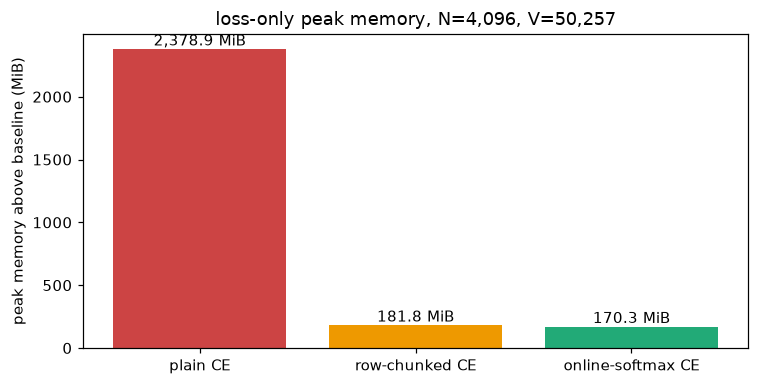

In [21]:
N, Vb, dmem = CFG["mem_rows"], CFG["mem_vocab"], CFG["d_model"]
CH, VC = CFG["chunk_rows"], CFG["vocab_chunk"]
MODES = ("plain", "chunked", "online")

if DEVICE == "cuda":
    def _peak(mode):
        torch.cuda.empty_cache()
        torch.manual_seed(0)
        hidden = torch.randn(N, dmem, device="cuda", requires_grad=True)
        W = (torch.randn(Vb, dmem, device="cuda") * 0.02).requires_grad_()
        targets = torch.randint(0, Vb, (N,), device="cuda")
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        base = torch.cuda.memory_allocated()          # the inputs themselves
        if mode == "plain":
            plain_ce(hidden, W, targets).backward()
        elif mode == "chunked":
            chunked_ce(hidden, W, targets, chunk_rows=CH).backward()
        else:
            online_ce(hidden, W, targets, vocab_chunk=VC).backward()
        torch.cuda.synchronize()
        return (torch.cuda.max_memory_allocated() - base) / 2**20
    mem_how = "CUDA allocator peak above the resident inputs (byte-exact)"
else:
    DRIVER = CE_IMPL_SRC + r"""
import gc, os, sys, threading, time
mode, N, V, d, chunk, vc = (sys.argv[1], int(sys.argv[2]), int(sys.argv[3]),
                            int(sys.argv[4]), int(sys.argv[5]), int(sys.argv[6]))
PAGE = os.sysconf("SC_PAGE_SIZE")


def rss_mib():
    # Linux: current resident set from /proc. Elsewhere (macOS): fall back to
    # the getrusage high-water mark — coarser, but the cell never crashes.
    try:
        with open("/proc/self/statm") as fh:
            return int(fh.read().split()[1]) * PAGE / 2**20
    except (FileNotFoundError, OSError):
        import resource
        ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return ru / 2**20 if sys.platform == "darwin" else ru / 1024


torch.manual_seed(0)
hidden = torch.randn(N, d, requires_grad=True)
W = (torch.randn(V, d) * 0.02).requires_grad_()
targets = torch.randint(0, V, (N,))

# warm-up OUTSIDE the measured window: spawn the thread pool and its scratch
# buffers once, so only the loss's own allocations are measured below
with torch.no_grad():
    (hidden[:64] @ W[:512].t()).sum()
gc.collect()

state = {"peak": 0.0, "stop": False}


def watch():
    while not state["stop"]:
        state["peak"] = max(state["peak"], rss_mib())
        time.sleep(0.001)


base = rss_mib()
state["peak"] = base
watcher = threading.Thread(target=watch)
watcher.start()
if mode == "plain":
    plain_ce(hidden, W, targets).backward()
elif mode == "chunked":
    chunked_ce(hidden, W, targets, chunk_rows=chunk).backward()
else:
    online_ce(hidden, W, targets, vocab_chunk=vc).backward()
state["stop"] = True
watcher.join()
print(max(state["peak"], rss_mib()) - base)
"""

    def _peak(mode):
        # MALLOC_MMAP_THRESHOLD_ pins glibc's dynamic mmap threshold, so freed
        # chunk buffers are returned to the OS immediately and the resident set
        # tracks the allocator instead of heap fragmentation.
        env = {**os.environ, "MALLOC_MMAP_THRESHOLD_": "131072"}
        out = subprocess.run([sys.executable, "-c", DRIVER, mode,
                              str(N), str(Vb), str(dmem), str(CH), str(VC)],
                             capture_output=True, text=True, check=True, env=env)
        return float(out.stdout.strip())               # MiB of RSS growth
    mem_how = ("resident-set growth during the loss call, sampled in-process, "
               "one fresh subprocess per variant (glibc mmap threshold pinned; "
               "/proc on Linux, getrusage fallback elsewhere)")

peaks = {m: _peak(m) for m in MODES}
ratio = peaks["plain"] / max(peaks["chunked"], 1e-9)
ratio_online = peaks["plain"] / max(peaks["online"], 1e-9)
logits_mib = N * Vb * 4 / 2**20
chunk_mib = CH * Vb * 4 / 2**20
online_mib = N * VC * 4 / 2**20

print(f"measurement: {mem_how}")
print(f"device={DEVICE}, N={N:,}, V={Vb:,}, d={dmem}, "
      f"row chunk={CH}, vocab chunk={VC}")
print("analytic largest logits buffer per variant:")
print(f"  plain       [N, V]  = {N:,} x {Vb:,} x 4B = {logits_mib:,.1f} MiB")
print(f"  row-chunked [{CH}, V] = {chunk_mib:,.1f} MiB")
print(f"  online      [N, {VC:,}] = {online_mib:,.1f} MiB   (independent of V)")
print(f"measured loss-attributable peaks:")
print(f"  plain CE       : {peaks['plain']:,.1f} MiB")
print(f"  row-chunked CE : {peaks['chunked']:,.1f} MiB   "
      f"({ratio:,.1f}x smaller than plain)")
print(f"  online CE      : {peaks['online']:,.1f} MiB   "
      f"({ratio_online:,.1f}x smaller than plain)")

(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 3.6), dpi=110)
labels = ["plain CE", "row-chunked CE", "online-softmax CE"]
vals = [peaks["plain"], peaks["chunked"], peaks["online"]]
bars = ax.bar(labels, vals, color=["#c44", "#e90", "#2a7"])
for b, v in zip(bars, vals):
    ax.annotate(f"{v:,.1f} MiB", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom")
ax.set_ylabel("peak memory above baseline (MiB)")
ax.set_title(f"loss-only peak memory, N={N:,}, V={Vb:,}")
fig.tight_layout()
fig.savefig(ART / "plots" / "memory_bars.png")
plt.show()

RESULTS["part1"]["memory"] = {
    "device": DEVICE, "how": mem_how, "N": N, "V": Vb, "d": dmem,
    "chunk_rows": CH, "vocab_chunk": VC,
    "peak_full_mb": peaks["plain"], "peak_chunked_mb": peaks["chunked"],
    "peak_online_mb": peaks["online"],
    "ratio": ratio, "ratio_online": ratio_online,
    "analytic_logits_mb": logits_mib, "analytic_chunk_mb": chunk_mib,
    "analytic_online_mb": online_mib,
}
HEADLINE["mem_full_mb"] = f"{peaks['plain']:,.1f}"
HEADLINE["mem_chunked_mb"] = f"{peaks['chunked']:,.1f}"
HEADLINE["mem_online_mb"] = f"{peaks['online']:,.1f}"
HEADLINE["mem_ratio"] = f"{ratio:,.1f}"
HEADLINE["mem_ratio_online"] = f"{ratio_online:,.1f}"

### §9b — one more scalar that fails silently: fp16 exponentials

Mixed-precision training keeps the *model* in fp16/bf16; the loss must not follow it
naively. `exp(12)` already overflows fp16's maximum of 65,504, and logits of magnitude
~12 are routine mid-training. A naive fp16 softmax turns into `inf/inf = nan` — no
exception, the loss simply goes `nan` (or worse, only *some* rows do). The two standard
defenses are shown side by side: the max-subtraction identity (what `log_softmax` does
internally, and what §9's online CE streams across chunks), and computing the loss in
fp32 regardless of model precision (what every serious trainer does).

In [22]:
logits16 = torch.tensor([[9.0, 11.0, 13.0]], dtype=torch.float16)
naive = torch.exp(logits16) / torch.exp(logits16).sum()
stable = torch.exp(logits16 - logits16.max())
stable = stable / stable.sum()
fp32 = torch.softmax(logits16.float(), dim=-1)

print(f"logits (fp16)                  : {logits16.tolist()}")
print(f"naive fp16 softmax             : {naive.tolist()}   <- exp(13) overflows")
print(f"max-subtracted fp16 softmax    : {[round(float(x), 4) for x in stable[0]]}")
print(f"fp32 softmax                   : {[round(float(x), 4) for x in fp32[0]]}")
assert torch.isnan(naive).any(), "the naive path must fail, that is the point"
assert torch.allclose(stable.float(), fp32, atol=1e-3)
RESULTS["part1"]["fp16_naive_is_nan"] = bool(torch.isnan(naive).any())

logits (fp16)                  : [[9.0, 11.0, 13.0]]
naive fp16 softmax             : [[0.0, 0.0, nan]]   <- exp(13) overflows
max-subtracted fp16 softmax    : [0.0159, 0.1174, 0.8672]
fp32 softmax                   : [0.0159, 0.1173, 0.8668]


## §10 — Part 2: a second head predicting t+2

A second linear head is bolted onto the *same* trunk — this is the parallel-heads
multi-token-prediction design of Gloeckle et al. (arXiv:2404.19737); DeepSeek-V3
(arXiv:2412.19437) uses a heavier sequential variant of the same idea. The alignments,
first **verified in strings** (this is still the print-the-strings notebook — Part 2
gets its own audit table below):

- head 1: `logits1[:, :-1]` answers for `tokens[:, 1:]` — the next token,
- head 2: `logits2[:, :-2]` answers for `tokens[:, 2:]` — the token after next
  (two prediction slots are lost at the end of the sequence, and any padding/boundary
  mask would shift by two identically).

**Both heads are untied.** The obvious construction — keep the tied `t+1` head, add a
fresh `[V, d]` matrix for `t+2` — measures the entropy gap *confounded* with "tied
embedding head vs randomly initialized head" (§7 just showed tying is not innocent). Two
identically-constructed untied heads differ only in *which shift they are asked about*,
which is the comparison the entropy argument is about.

Training minimizes the plain sum `L1 + L2` for 600 steps. Instrumentation protocol,
stated so the numbers can be trusted: **step 0 is logged before the first optimizer
update** (both heads genuinely ignorant); the per-step train values are pre-update
minibatch losses and are shown in the plot only; every **held-out** point and every
**reported final** is a deterministic full-stream sweep (consecutive windows, every
target counted once), not a frozen batch of random crops.

**What to expect, and why.** At step 0 — logged before any update — both heads sit at
`ln V` and the gap is zero: before the model knows anything, one step ahead and two
steps ahead are equally unknowable. Then both losses fall, and a gap **opens with `L2`
above `L1`**: predicting `t+2` means marginalizing over the unknown token in between,
and conditioning on strictly less information can never help —
`H(x_{t+2} | x_{≤t}) ≥ H(x_{t+2} | x_{≤t+1})`, and the right-hand side is head 1's own
task one step later (by stationarity). The gap *is* the information carried by the
skipped token, and the model has to learn the language before that information is worth
anything — which is why the gap grows as the losses shrink. Watch the two splits
separately: on the **held-out** sweep the gap keeps growing late into training — the
entropy argument is about the language, and generalization cannot cheat it. On the
**training** stream, where an over-parameterized model slowly memorizes the ~6.6 KB
corpus, the gap stops growing and plateaus below the held-out gap — memorization makes
the skipped token partly known, capping what the gap can be made of. That asymmetry is
the memorization signature, reported rather than averaged away.

part-2 alignment audit, in strings (one row per prediction position):
   pos    read  t+1 demands  t+2 demands
     0       =            ␣            m
     1       ␣            m            o
     2       m            o            d
     3       o            d            e
     4       d            e            l
     5       e            l            .
     6       l            .            t
     7       .            t            r
     8       t            r            u
     9       r            u            n
    10       u            n            k
    11       n            k            (
    12       k            (            t
    13       (            t            o
  exact identity: targets2[i] == tokens[i+2] for every slot -> True

  step    0  loss=11.1248  L1=5.5834 L2=5.5415


  step   20  loss=6.1236  L1=3.0622 L2=3.0614


  step   40  loss=5.9975  L1=2.9923 L2=3.0052


  step   60  loss=5.6607  L1=2.7413 L2=2.9194


  step   80  loss=5.5298  L1=2.6649 L2=2.8650


...

  step  520  loss=4.8894  L1=2.2875 L2=2.6019


  step  540  loss=4.6486  L1=2.1775 L2=2.4712


  step  560  loss=4.8710  L1=2.2936 L2=2.5774


  step  580  loss=4.6625  L1=2.1928 L2=2.4697


  step  600  loss=4.7041  L1=2.1922 L2=2.5119
final train (full-stream sweep): L1=2.1711  L2=2.4816  sum=4.6526
final held  (full-stream sweep): L1=2.5650  L2=2.9629  sum=5.5278
held-out gap L2-L1: -0.0183 at step 0 (pre-update) -> 0.3979 at the end


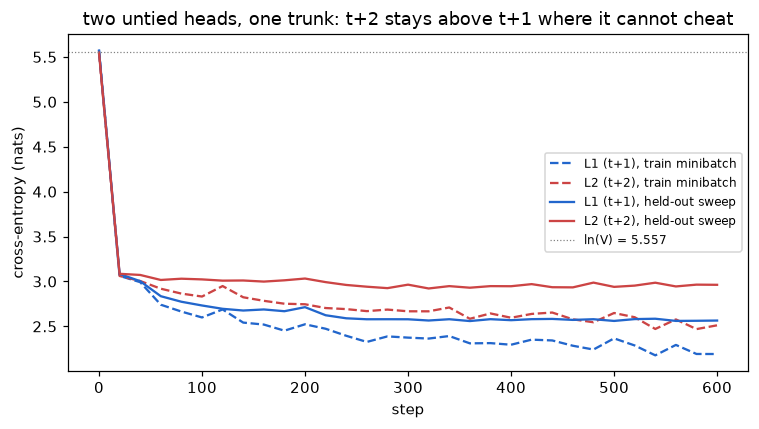

In [23]:
seed_all()
audit_tokens = sample_batch(TRAIN_STREAM, 1, 16, random.Random(SEED + 7))
print("part-2 alignment audit, in strings (one row per prediction position):")
print(f"  {'pos':>4} {'read':>7} {'t+1 demands':>12} {'t+2 demands':>12}")
for i in range(audit_tokens.shape[1] - 2):
    print(f"  {i:>4} {decode_token(int(audit_tokens[0, i])):>7} "
          f"{decode_token(int(audit_tokens[0, i + 1])):>12} "
          f"{decode_token(int(audit_tokens[0, i + 2])):>12}")
t2 = audit_tokens[:, 2:]
for i in range(t2.shape[1]):
    assert int(t2[0, i]) == int(audit_tokens[0, i + 2])
print("  exact identity: targets2[i] == tokens[i+2] for every slot -> True\n")

model_mtp, curve_mtp = train_arm("correct", CFG["steps_part2"], two_heads=True)
CURVES["part2"] = curve_mtp

# reported finals: deterministic full-stream sweeps, not the last minibatch
f_tr_L1 = eval_sweep(model_mtp, TRAIN_STREAM, 1)
f_tr_L2 = eval_sweep(model_mtp, TRAIN_STREAM, 2, use_head2=True)
f_hd_L1 = eval_sweep(model_mtp, HELD_STREAM, 1)
f_hd_L2 = eval_sweep(model_mtp, HELD_STREAM, 2, use_head2=True)
gap_step0 = curve_mtp["held_L2"][0] - curve_mtp["held_L1"][0]
gap_last = f_hd_L2 - f_hd_L1

print(f"final train (full-stream sweep): L1={fmt(f_tr_L1)}  L2={fmt(f_tr_L2)}  "
      f"sum={fmt(f_tr_L1 + f_tr_L2)}")
print(f"final held  (full-stream sweep): L1={fmt(f_hd_L1)}  L2={fmt(f_hd_L2)}  "
      f"sum={fmt(f_hd_L1 + f_hd_L2)}")
print(f"held-out gap L2-L1: {fmt(gap_step0)} at step 0 (pre-update) -> "
      f"{fmt(gap_last)} at the end")

(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
s = curve_mtp["step"]
ax.plot(s, curve_mtp["train_L1"], "--", color="#26c",
        label="L1 (t+1), train minibatch")
ax.plot(s, curve_mtp["train_L2"], "--", color="#c44",
        label="L2 (t+2), train minibatch")
ax.plot(s, curve_mtp["held_L1"], "-", color="#26c",
        label="L1 (t+1), held-out sweep")
ax.plot(s, curve_mtp["held_L2"], "-", color="#c44",
        label="L2 (t+2), held-out sweep")
ax.axhline(math.log(VOCAB_SIZE), color="gray", lw=0.8, ls=":",
           label=f"ln(V) = {math.log(VOCAB_SIZE):.3f}")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy (nats)")
ax.set_title("two untied heads, one trunk: t+2 stays above t+1 where it cannot cheat")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ART / "plots" / "mtp_gap.png")
plt.show()

RESULTS["part2"] = {
    "final": {"train_L1": f_tr_L1, "train_L2": f_tr_L2,
              "train_sum": f_tr_L1 + f_tr_L2,
              "held_L1": f_hd_L1, "held_L2": f_hd_L2,
              "held_sum": f_hd_L1 + f_hd_L2},
    "final_logged": {"train_L1": curve_mtp["train_L1"][-1],
                     "train_L2": curve_mtp["train_L2"][-1],
                     "held_L1": curve_mtp["held_L1"][-1],
                     "held_L2": curve_mtp["held_L2"][-1]},
    "held_gap_step0": gap_step0, "held_gap_final": gap_last,
    "heads_untied": model_mtp.head.weight is not model_mtp.tok_emb.weight,
}
for k, v in RESULTS["part2"]["final"].items():
    HEADLINE[f"p2_{k}"] = fmt(v)

## §11 — Part 3: the bug zoo, or why a beautiful curve proves nothing

Same architecture, same initialization, same crop sequence, same optimizer, same budget as
the §4 correct arm. The three arms differ **only** in the two slicing lines:

| arm | prediction slice | target slice | what position *t* is asked |
|---|---|---|---|
| `correct` | `logits[:, :-1]` | `tokens[:, 1:]` | the token it has **not** seen |
| `reversed` | `logits[:, 1:]` | `tokens[:, :-1]` | the token it read **one step ago** |
| `no_shift` | `logits` | `tokens` | the token **in its own input** |

Both bugs hand the network a target that already sits inside its receptive field — but
**the two copy circuits are not the same circuit**, and the curves show it. `no_shift`
collapses within the first ~20 steps: §7 proved its wire is an *architectural identity*
(tied head × residual stream), so the optimizer only has to amplify what initialization
already built. `reversed` tracks the correct arm for over a hundred steps and then falls
off a cliff: predicting token `t−1` from position `t` requires an actual **attention**
circuit — attend one position back, route that embedding to the output — and attention
circuits take time to form. Same family of bug, different mechanism, and the loss curve
alone cannot tell you either fact. What it does show is the assignment's warning,
quantified: **all three curves fall smoothly (batch-to-batch jitter aside), and the two
broken ones end far *lower* than the correct one.**

Three instruments distinguish and *name* them:

1. **`audit_shift`** — the §4 string audit, run on each arm's actual `(input, target)`
   tensors. One screen of strings names the objective each arm was really given.
2. **Copy-circuit accuracies** — the claim-carrying metric, logged every 20 steps for
   every arm: greedy-argmax agreement with *next token* (the objective we want), with
   *self* (the identity circuit), and with *previous token* (the attend-back circuit).
   The correct arm's next-token accuracy rises while both copy accuracies idle near
   chance; `reversed` drives copy-prev to ~1.0; `no_shift` drives copy-self to ~1.0.
   That triple *names the circuit from the weights' behavior alone*.
3. **Generation** — 200 tokens sampled at temperature 0.8 (seeded). Note what this
   measures: sampling always feeds `argmax/sample of logits[t]` back as the *next* token
   — the standard inference protocol assumes the next-token alignment. The buggy models
   were trained on a different alignment, so under this protocol they emit their own
   input back: an unbroken `<bos> <bos> <bos> …` run. That is not a generation bug; it
   is **train/inference mismatch made audible**, and it is the lesson. The 4-gram hit
   rate against the corpus is reported as color (the correct arm's sample is
   byte-level word-salad *in corpus register*, not language) — the claim rests on the
   accuracies above, not on 4-grams.

In [24]:
model_rev, curve_rev = train_arm("reversed", CFG["steps_zoo"], quiet=True,
                                 track_copy=True)
model_nos, curve_nos = train_arm("no_shift", CFG["steps_zoo"], quiet=True,
                                 track_copy=True)
CURVES["zoo_reversed"], CURVES["zoo_no_shift"] = curve_rev, curve_nos

zoo_models = {"correct": model_correct, "reversed": model_rev, "no_shift": model_nos}
zoo_curves = {"correct": curve_correct, "reversed": curve_rev, "no_shift": curve_nos}

seed_all()
probe = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], random.Random(SEED + 3))
zoo = {}
for name in ("correct", "reversed", "no_shift"):
    print("=" * 72)
    a = audit_shift(probe, ARMS[name], title=f"{name} arm")
    ids = generate(zoo_models[name])
    text = decode(ids)
    rate = four_gram_hit_rate(text, CORPUS_TEXT)
    cv = zoo_curves[name]
    accs = {k: cv[f"acc_{k}"][-1] for k in ("next", "self", "prev")}
    print(f"  first tokens emitted: {' '.join(decode_token(t) for t in ids[1:13])}")
    print(f"  sampled text (T=0.8): {text[:70]!r}")
    print(f"  final accuracies  next={accs['next']:.3f}  self={accs['self']:.3f}"
          f"  prev={accs['prev']:.3f}")
    print(f"  4-gram hit rate vs corpus (color, not claim): {rate:.3f}")
    zoo[name] = {"final_loss": cv["loss"][-1],
                 "verdict": a["verdict"], "rates": a["rates"],
                 "acc_next": accs["next"], "acc_self": accs["self"],
                 "acc_prev": accs["prev"],
                 "gram4": rate, "sample": text[:120]}

print("=" * 72)
print(f"{'arm':<10} {'final loss':>10} {'verdict':>10} "
      f"{'next':>7} {'self':>7} {'prev':>7} {'4-gram':>8}")
for name, z in zoo.items():
    print(f"{name:<10} {fmt(z['final_loss']):>10} {z['verdict']:>10} "
          f"{z['acc_next']:>7.3f} {z['acc_self']:>7.3f} {z['acc_prev']:>7.3f} "
          f"{z['gram4']:>8.3f}")

shift audit: correct arm
  position:  0  1  2  3  4  5  6  7  8  9 10 11 12 13
  input   :  f  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r   (last token read)
  target  :  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r  e   (token demanded)
  match rate reversed(-1): 0.0268
  match rate  identity(0): 0.0157
  match rate  correct(+1): 1.0000
  verdict: CORRECT


  first tokens emitted: t t i ␣ m e s s ␣ w a n
  sampled text (T=0.8): 'tti mess wan italondndrts ti neringe nts whintlesle ika an ces ive ten'
  final accuracies  next=0.288  self=0.003  prev=0.098
  4-gram hit rate vs corpus (color, not claim): 0.259
shift audit: reversed arm
  position:  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  input   :  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r  e   (last token read)
  target  :  f  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r   (token demanded)
  match rate reversed(-1): 1.0000
  match rate  identity(0): 0.0157
  match rate  correct(+1): 0.0268
  verdict: REVERSED


  first tokens emitted: <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>
  sampled text (T=0.8): ''
  final accuracies  next=0.027  self=0.023  prev=0.999
  4-gram hit rate vs corpus (color, not claim): 0.000
shift audit: no_shift arm
  position:  0  1  2  3  4  5  6  7  8  9 10 11 12 13
  input   :  f  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r   (last token read)
  target  :  f  ␣  o  n  e  ␣  e  s  s  a  y  ␣  p  r   (token demanded)
  match rate reversed(-1): 0.0157
  match rate  identity(0): 1.0000
  match rate  correct(+1): 0.0157
  verdict: IDENTITY


  first tokens emitted: <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>
  sampled text (T=0.8): ''
  final accuracies  next=0.016  self=1.000  prev=0.016
  4-gram hit rate vs corpus (color, not claim): 0.000
arm        final loss    verdict    next    self    prev   4-gram
correct        2.3793    CORRECT   0.288   0.003   0.098    0.259
reversed       0.0102   REVERSED   0.027   0.023   0.999    0.000
no_shift       0.0000   IDENTITY   0.016   1.000   0.016    0.000


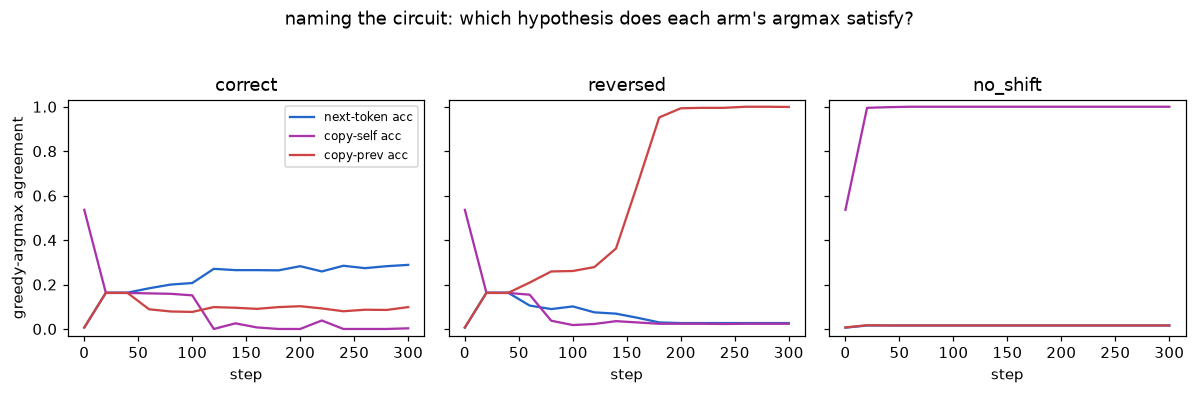

In [25]:
(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), dpi=110, sharey=True)
for ax, name in zip(axes, ("correct", "reversed", "no_shift")):
    cv = zoo_curves[name]
    ax.plot(cv["step"], cv["acc_next"], color="#26c", label="next-token acc")
    ax.plot(cv["step"], cv["acc_self"], color="#a3a", label="copy-self acc")
    ax.plot(cv["step"], cv["acc_prev"], color="#c44", label="copy-prev acc")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("greedy-argmax agreement")
axes[0].legend(fontsize=8)
fig.suptitle("naming the circuit: which hypothesis does each arm's argmax satisfy?",
             y=1.04)
fig.tight_layout()
fig.savefig(ART / "plots" / "copy_circuits.png", bbox_inches="tight")
plt.show()

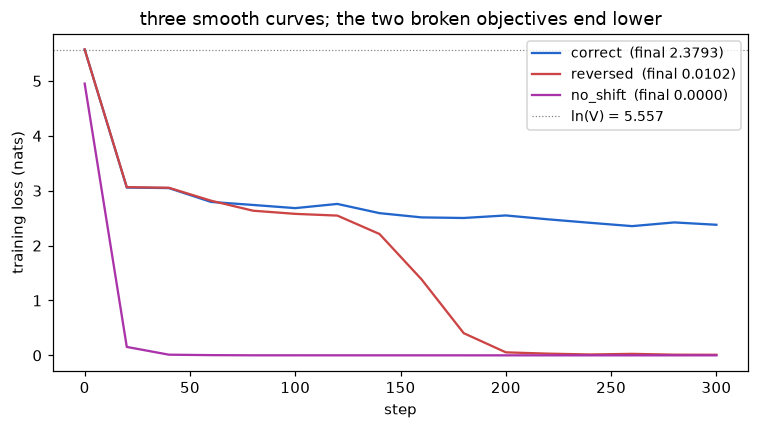

In [26]:
(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
colors = {"correct": "#26c", "reversed": "#c44", "no_shift": "#a3a"}
for name, c in zoo_curves.items():
    ax.plot(c["step"], c["loss"], color=colors[name],
            label=f"{name}  (final {fmt(c['loss'][-1])})")
ax.axhline(math.log(VOCAB_SIZE), color="gray", lw=0.8, ls=":",
           label=f"ln(V) = {math.log(VOCAB_SIZE):.3f}")
ax.set_xlabel("step"); ax.set_ylabel("training loss (nats)")
ax.set_title("three smooth curves; the two broken objectives end lower")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(ART / "plots" / "bug_zoo_curves.png")
plt.show()

RESULTS["part3"] = {"arms": zoo}
for name, z in zoo.items():
    HEADLINE[f"zoo_{name}_final"] = fmt(z["final_loss"])
    HEADLINE[f"zoo_{name}_gram4"] = f"{z['gram4']:.3f}"
HEADLINE["zoo_correct_next_acc"] = f"{zoo['correct']['acc_next']:.3f}"
HEADLINE["zoo_reversed_prev_acc"] = f"{zoo['reversed']['acc_prev']:.3f}"
HEADLINE["zoo_no_shift_self_acc"] = f"{zoo['no_shift']['acc_self']:.3f}"

## §12 — Every number, written to disk

`submission_artifacts/results.json` holds the seven Part-1 numbers, Part 2's losses, and
the Part-3 table; `loss_curves.json` the raw curves; `per_token_losses.json` the raw
per-token vectors behind §5/§6. The repo's `audit.py` re-derives each claim from these
files without executing this notebook, and checks that every `headline` value below
appears **verbatim** in the README — nothing in the write-up is retyped by hand.

In [27]:
RESULTS["wall_seconds"] = round(time.time() - T0, 1)
RESULTS["headline"] = HEADLINE

ART.mkdir(parents=True, exist_ok=True)
(ART / "results.json").write_text(json.dumps(RESULTS, indent=2))
(ART / "loss_curves.json").write_text(json.dumps(CURVES, indent=2))
(ART / "per_token_losses.json").write_text(json.dumps(PTL, indent=2))
(ART / "run_config.json").write_text(json.dumps(RESULTS["config"], indent=2))

p1 = RESULTS["part1"]
print("the seven numbers (Part 1):")
print(f"  1. logits shape {tuple(p1['shapes']['logits'])}  "
      f"[B sequences, T positions, V vocabulary scores]")
print(f"  2. shift audit: correct(+1) match rate {HEADLINE['shift_rate_correct']}")
print(f"  3. contributing targets {HEADLINE['pad_slots']} -> {HEADLINE['pad_contributing']}"
      f"  (loss {HEADLINE['pad_loss_unmasked']} -> {HEADLINE['pad_loss_masked']};"
      f" wrong-mean bug reads {HEADLINE['pad_loss_wrongmean']})")
print(f"  4. packed loss {HEADLINE['pack_loss_before']} -> {HEADLINE['pack_loss_after']}"
      f"  after masking {p1['packing']['n_boundary']} boundary targets")
print(f"  5. untrained perplexity {HEADLINE['untrained_ppl']}  (V = {VOCAB_SIZE});"
      f"  tied no_shift leaks to {HEADLINE['leak_noshift_tied_ppl']} at init")
print(f"  6. params tied {HEADLINE['params_tied']} vs untied {HEADLINE['params_untied']}"
      f"  (delta {HEADLINE['params_delta']} = V*d)")
print(f"  7. loss peak memory {HEADLINE['mem_full_mb']} -> "
      f"{HEADLINE['mem_chunked_mb']} (row-chunked, {HEADLINE['mem_ratio']}x) -> "
      f"{HEADLINE['mem_online_mb']} MiB (online, {HEADLINE['mem_ratio_online']}x)")
print("Part 2 (untied heads, full-stream sweeps):")
print(f"  held-out L1 {HEADLINE['p2_held_L1']}  L2 {HEADLINE['p2_held_L2']}"
      f"  sum {HEADLINE['p2_held_sum']}")
print("Part 3:")
print(f"  losses: correct {HEADLINE['zoo_correct_final']} / reversed "
      f"{HEADLINE['zoo_reversed_final']} / no_shift {HEADLINE['zoo_no_shift_final']}"
      f"  (lower is NOT better)")
print(f"  circuits named: reversed copy-prev acc {HEADLINE['zoo_reversed_prev_acc']},"
      f" no_shift copy-self acc {HEADLINE['zoo_no_shift_self_acc']},"
      f" correct next-token acc {HEADLINE['zoo_correct_next_acc']}")
print(f"\nwall time: {RESULTS['wall_seconds']}s on {DEVICE}")
print("NOTEBOOK COMPLETE")

the seven numbers (Part 1):
  1. logits shape (8, 128, 259)  [B sequences, T positions, V vocabulary scores]
  2. shift audit: correct(+1) match rate 1.0000
  3. contributing targets 508 -> 186  (loss 10.3600 -> 2.2887; wrong-mean bug reads 0.8380)
  4. packed loss 2.5564 -> 2.5363  after masking 2 boundary targets
  5. untrained perplexity 261.3  (V = 259);  tied no_shift leaks to 143.5 at init
  6. params tied 495,488 vs untied 528,640  (delta 33,152 = V*d)
  7. loss peak memory 2,378.9 -> 181.8 (row-chunked, 13.1x) -> 170.3 MiB (online, 14.0x)
Part 2 (untied heads, full-stream sweeps):
  held-out L1 2.5650  L2 2.9629  sum 5.5278
Part 3:
  losses: correct 2.3793 / reversed 0.0102 / no_shift 0.0000  (lower is NOT better)
  circuits named: reversed copy-prev acc 0.999, no_shift copy-self acc 1.000, correct next-token acc 0.288

wall time: 50.1s on cpu
NOTEBOOK COMPLETE
